# Beyond Subsidies: Identifying Commercially Viable EV Charging Infrastructure Investment in Australia

## Project Overview

This notebook documents the full data engineering and machine learning pipeline for analysing electric vehicle (EV) adoption patterns and charging infrastructure investment viability across Australia.

**Research Question:** Which Australian regions represent genuine private investment opportunities for EV charging infrastructure, independent of government subsidy support?

**Methodology:** A two-layer analytical framework combining:

- **Demand modelling:** XGBoost model forecasting regional EV adoption (2026–2030) from socioeconomic, geographic, policy, and infrastructure features, producing two demand scenarios — Layer 1 (As-Forecasted), which carries each region's current subsidy status forward, and Layer 2 (Organic-Only), a counterfactual growth path derived from states where subsidies have already ended.
- **Two-layer DCF with financial sensitivity:** Both demand layers are evaluated under three financial scenarios (optimistic / base / conservative, varying utilisation targets, CapEx, and discount rate), producing 6 NPV estimates per SA2. These are combined into a two-axis robustness classification — separating sensitivity to demand assumptions from sensitivity to cost assumptions — to identify regions that are commercially viable without subsidy support, versus those that remain subsidy-dependent or not viable under any tested scenario.

**Authors:** Cong, Quang

**Institution:** Macquarie University

**Data Period:** 2021–2025 (historical) | 2026–2030 (forecast)

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1. Geographic Boundaries | Load SA2 and Postal Area shapefiles |
| 2. EV Registration Data | Load and clean AAA EV Index data |
| 3. Spatial Integration | Join postcode-level EV data to SA2 boundaries |
| 4. Feature Engineering | Add demographics, infrastructure, and policy features |
| 5. Exploratory Data Analysis | National adoption trend, state comparison, feature correlations, the policy cliff, multicollinearity check |
| 6. Machine Learning Model & Forecasting | XGBoost adoption forecasting, 2026–2030 rolling forecast |
| 7. Two-Layer DCF Analysis | As-forecasted vs organic-only demand layers × 3 financial scenarios, two-axis robustness classification, infrastructure gap analysis |

In [1]:
# ── PROJECT CONFIG — set this once ───────────────────────────────
# Running the notebook on any machine only requires the folder
# structure below, relative to BASE_DIR (defaults to the folder
# containing this notebook).
from pathlib import Path
import os

# Can be overridden with the EV_PROJECT_DIR environment variable;
# otherwise defaults to the notebook's current directory.
BASE_DIR = Path(os.environ.get('EV_PROJECT_DIR', '.')).resolve()

RAW_DIR = BASE_DIR / 'raw'
CLEAN_DIR = BASE_DIR / 'clean'

# Auto-create the output folder if missing (raw data must be provided manually)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR  = {BASE_DIR}")
print(f"RAW_DIR   = {RAW_DIR}  (place all source files here — shapefiles, xlsx, csv)")
print(f"CLEAN_DIR = {CLEAN_DIR}  (intermediate outputs and figures are saved here)")


BASE_DIR  = /Users/bob/Downloads/EV data
RAW_DIR   = /Users/bob/Downloads/EV data/raw  (place all source files here — shapefiles, xlsx, csv)
CLEAN_DIR = /Users/bob/Downloads/EV data/clean  (intermediate outputs and figures are saved here)


In [2]:
# ── SHARED IMPORTS — used throughout the notebook ────────────────
# Library-specific imports used only once (requests, sklearn, xgboost, ...)
# remain at their first point of use further down.
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Known fake / summary-row postcodes in the AAA registration dataset
# (footer rows, not real postcodes) — defined once, reused throughout.
FAKE_POSTCODES = ['9494', '9797', 'ZZZZ']


## Section 1: Geographic Boundaries

### 1.1 SA2 Statistical Boundaries

Australia is divided into 2,473 Statistical Areas Level 2 (SA2) — the primary geographic unit for this analysis. SA2 regions represent communities with populations of 3,000–25,000 people, providing a meaningful balance between geographic granularity and data reliability.

**Source:** Australian Bureau of Statistics (ABS) — ASGS Edition 3, GDA2020
**File:** SA2_2021_AUST_GDA2020.shp

In [3]:

sa2 = gpd.read_file(RAW_DIR / 'SA2_2021_AUST_SHP_GDA2020')

print(f"Shape: {sa2.shape}")        
print(f"CRS: {sa2.crs}")            

Shape: (2473, 17)
CRS: EPSG:7844


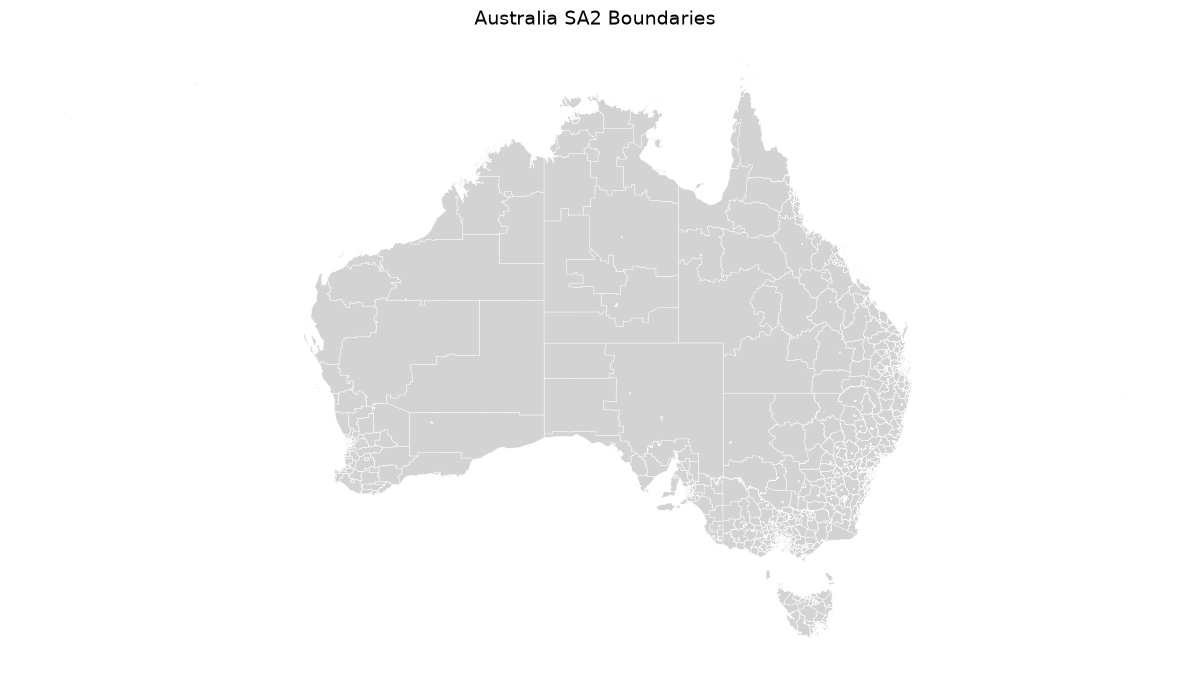

In [4]:

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

sa2.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.3
)

ax.set_title('Australia SA2 Boundaries', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(RAW_DIR / 'sa2_boundaries.png', dpi=150)
plt.show()

### 1.2 Postal Area Boundaries

Postal Areas (POA) are the ABS approximation of Australian postcodes. Since the AAA EV registration dataset uses postcodes as its geographic identifier, we load POA boundaries to bridge between postcode-level EV data and SA2-level analytical geography.

**Source:** ABS — ASGS Edition 3
**File:** POA_2021_AUST_GDA2020.shp

**Note:** The SA2 shapefile uses GDA94 (EPSG:4283). All spatial operations are reprojected to GDA94 Albers Equal Area (EPSG:3577) to ensure geometrically accurate centroid calculations in metres rather than degrees.

In [5]:
# poa is loaded here; sa2 was already loaded in the previous cell (reused, not reloaded)
poa = gpd.read_file(RAW_DIR / 'POA_2021_AUST_GDA2020_SHP')

print(sa2.shape)
sa2.head()


(2473, 17)


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.218 -35.366..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.1997 -35.35..."


In [6]:
print(poa.shape)
poa.head()

(2644, 9)


,POA_CODE21,POA_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,SHAPE_Leng,SHAPE_Area,geometry
0,0800,0800,AUS,Australia,3.1731,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.081893,0.000264,"POLYGON ((130.83681 -12.45376, 130.83684 -12.4..."
1,0810,0810,AUS,Australia,24.4283,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.241859,0.002031,"POLYGON ((130.89986 -12.36567, 130.89875 -12.3..."
2,0812,0812,AUS,Australia,35.8899,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.278788,0.002983,"POLYGON ((130.91915 -12.40786, 130.91831 -12.4..."
3,0820,0820,AUS,Australia,39.0642,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.409134,0.003248,"POLYGON ((130.8526 -12.43994, 130.85089 -12.43..."
4,0822,0822,AUS,Australia,150775.8030,http://linked.data.gov.au/dataset/asgsed3/POA/...,90.601831,12.564238,"MULTIPOLYGON (((136.56648 -12.08392, 136.56704..."


## Section 2: EV Registration Data

### 2.1 AAA EV Index — Registration Data (2021–2025)

The Australian Automobile Association (AAA) EV Index provides postcode-level vehicle registration counts by fuel type at January 31 each year from 2021 to 2025. This is the primary target variable source for the ML adoption model.

**Source:** Australian Automobile Association (AAA) EV Index
**Coverage:** All Australian postcodes, annual snapshots
**Fuel types:** BEV (Battery Electric), Hybrid/PHEV, ICE (Internal Combustion Engine)
**Format:** Wide format — one row per postcode × fuel type, 5 annual columns

**Key variable derived:** `adoption_rate` = BEV count / total fleet count per postcode per year

In [7]:
# Load AAA registration data
ev = pd.read_excel(RAW_DIR / 'EV_Index_Registration_Data_2021-2025.xlsx', sheet_name = "Registration Numbers")

print(f"EV data shape: {ev.shape}")
print(f"EV columns: {ev.columns.tolist()}")
ev.head()

EV data shape: (7302, 8)
EV columns: ['Postcode', 'State', 'Fuel Type', '31-Jan-2021', '31-Jan-2022', '31-Jan-2023', '31-Jan-2024', '31-Jan-2025']


,Postcode,State,Fuel Type,31-Jan-2021,31-Jan-2022,31-Jan-2023,31-Jan-2024,31-Jan-2025
0,800,NT,BEV,3,3,12,20,38
1,800,NT,Hybrid/PHEV,131,413,401,435,613
2,800,NT,ICE,6780,7313,7088,6574,6287
3,810,NT,BEV,6,16,22,75,155
4,810,NT,Hybrid/PHEV,288,375,467,592,961


### 2.2 Data Standardisation

Australian postcodes are 4-digit codes. The raw AAA data stores postcodes as integers (e.g. 800 for Darwin), while ABS geographic files use zero-padded strings (e.g. '0800'). All postcode fields are standardised to 4-digit zero-padded strings before any join operations to prevent silent match failures.

In [8]:
# Standardise postcode format in EV data
ev['Postcode'] = ev['Postcode'].astype(str).str.zfill(4)
print(ev['Postcode'].head())
print(poa['POA_CODE21'].head())

0    0800
1    0800
2    0800
3    0810
4    0810
Name: Postcode, dtype: str
0    0800
1    0810
2    0812
3    0820
4    0822
Name: POA_CODE21, dtype: str


### 2.3 Data Quality Checks (before merging)

Before `ev` is fed into the `merge`/`spatial join` operations in Section 3, we validate data quality on the raw table itself. Reasons to check here rather than after merging:

- **Nulls/negative values found after a merge only reflect the consequence of the join** (postcodes that failed to match between the two tables), not whether the original `ev` table was clean. Mixing these two error sources together makes debugging harder.
- **Duplicate rows cause silent fan-out during merges** — if a postcode has two rows for the same `Fuel Type`, the `merge` will duplicate the corresponding rows on the geography side **without producing any null values** to flag it. This cannot be caught by the `isna()` checks used in Section 3 — only a `duplicated()` check on the raw data can catch it.
- Catching issues early narrows down where a bug originates: if `adoption_rate` in Section 3.6 later produces an implausible value, we already know it isn't coming from `ev` itself (verified clean here), so the cause must be in the downstream logic.

In [9]:
# ── 2.3 DATA QUALITY CHECKS — run on raw data, before merging ──

year_cols = ['31-Jan-2021', '31-Jan-2022', '31-Jan-2023',
             '31-Jan-2024', '31-Jan-2025']

# 1. Missing values across the year columns
print("── Missing values per year column ──")
print(ev[year_cols].isna().sum())

# 2. Negative values — registration counts can never be negative
negative_counts = (ev[year_cols] < 0).sum()
print("\n── Negative values per year column ──")
print(negative_counts)
if negative_counts.sum() > 0:
    print("⚠ Negative values found — investigate the AAA source before continuing.")

# 3. Duplicate rows — a postcode should not have two rows for the same Fuel Type
dupes_mask = ev.duplicated(subset=['Postcode', 'Fuel Type'], keep=False)
print(f"\n── Duplicate rows (Postcode, Fuel Type): {dupes_mask.sum()} ──")
if dupes_mask.sum() > 0:
    print(ev[dupes_mask].sort_values(['Postcode', 'Fuel Type']))

# 4. Category consistency — catch 'BEV ' vs 'BEV', typos, etc.
print("\n── Fuel Type values ──")
print(ev['Fuel Type'].value_counts(dropna=False))
whitespace_issue = ev['Fuel Type'].astype(str).str.strip().ne(ev['Fuel Type'].astype(str)).sum()
print(f"Rows with extra whitespace in Fuel Type: {whitespace_issue}")

# 5. Anomalies — registration count decreasing between adjacent years
# (registrations rarely fall in bulk unless there's a measurement error or mass deregistration)
decline_flags = pd.Series(False, index=ev.index)
for i in range(len(year_cols) - 1):
    decline_flags |= (ev[year_cols[i+1]] < ev[year_cols[i]])
print(f"\n── Rows with a decline in at least one adjacent-year pair: {decline_flags.sum()} ──")
if decline_flags.sum() > 0:
    print(ev[decline_flags][['Postcode', 'State', 'Fuel Type'] + year_cols].head(10))

# ── FIX (defensive — only has an effect if the checks above found issues) ──
before = len(ev)
ev = ev.drop_duplicates(subset=['Postcode', 'Fuel Type'], keep='first')
ev['Fuel Type'] = ev['Fuel Type'].astype(str).str.strip()
after = len(ev)
print(f"\nRow count before/after removing duplicates: {before} → {after}")


── Missing values per year column ──
31-Jan-2021    0
31-Jan-2022    0
31-Jan-2023    0
31-Jan-2024    0
31-Jan-2025    0
dtype: int64

── Negative values per year column ──
31-Jan-2021    0
31-Jan-2022    0
31-Jan-2023    0
31-Jan-2024    0
31-Jan-2025    0
dtype: int64

── Duplicate rows (Postcode, Fuel Type): 0 ──

── Fuel Type values ──
Fuel Type
ICE            2635
Hybrid/PHEV    2525
BEV            2142
Name: count, dtype: int64
Rows with extra whitespace in Fuel Type: 0

── Rows with a decline in at least one adjacent-year pair: 2414 ──
   Postcode State    Fuel Type  31-Jan-2021  31-Jan-2022  31-Jan-2023  \
1      0800    NT  Hybrid/PHEV          131          413          401   
2      0800    NT          ICE         6780         7313         7088   
5      0810    NT          ICE        21856        22087        21901   
8      0812    NT          ICE        11913        11830        11736   
11     0820    NT          ICE        19896        19781        20432   
12     0822 

## Section 3: Spatial Integration

### 3.1 Merge EV Data to Postal Area Boundaries

We perform a left join from POA shapefile onto filtered EV data, matching on standardised postcode. This attaches geographic polygon geometry to each postcode's EV registration record, enabling subsequent spatial operations.

**Expected match rate:** ~81% — the remaining 19% are POA boundaries for uninhabited or industrial postcodes with no vehicle registrations in the AAA dataset. These are retained with zero BEV counts rather than dropped, preserving regional coverage for the ML model.

In [10]:
# Merge EV data with POA shapefile on postcode
ev_geo = poa.merge(
    ev[ev['Fuel Type'] == 'BEV'],  # BEV only for now
    left_on='POA_CODE21',
    right_on='Postcode',
    how='left'
)
print(f"Shape after merge: {ev_geo.shape}")
print(f"Null count in 31-Jan-2025: {ev_geo['31-Jan-2025'].isna().sum()}")

Shape after merge: (2644, 17)
Null count in 31-Jan-2025: 502


In [11]:
# How many POAs matched EV data?
matched = ev_geo['31-Jan-2025'].notna().sum()
total = len(ev_geo)
print(f"Matched: {matched}/{total} ({matched/total*100:.1f}%)")

Matched: 2142/2644 (81.0%)


### 3.2 Spatial Projection and Centroid Calculation

Geographic coordinates in degrees (EPSG:4283) are reprojected to GDA94 Albers Equal Area (EPSG:3577) — a projected CRS measured in metres — before centroid computation. This is essential for spatial accuracy: degree-based centroids introduce geometric errors proportional to distance from the equator, which would misassign large remote postcodes to incorrect SA2 regions.


In [12]:

# ── 1. RELOAD CLEAN INPUTS ──────────────────────────────────────
sa2_projected = sa2.to_crs(epsg=3577)

ev_geo_projected = ev_geo.to_crs(epsg=3577)
ev_geo_projected['geometry'] = ev_geo_projected.geometry.centroid

### 3.3 Spatial Join: Postcode Centroids to SA2 Boundaries

Each postcode centroid is assigned to the SA2 region it falls within using a point-in-polygon spatial join. Coastal postcodes where the centroid lands in ocean (outside any SA2 polygon) are resolved using a nearest-neighbour fallback join.

**Fake postcodes removed:** 9494, 9797, ZZZZ — AAA dataset summary/footer rows
**External territories excluded:** Christmas Island (6798, 6799), Cocos Islands (2898, 2899), and two uninhabited WA postcodes (6427, 6182) — no SA2 boundaries exist for these territories

In [13]:
# ── 2. PRIMARY SPATIAL JOIN (within) ───────────────────────────
ev_sa2 = gpd.sjoin(
    ev_geo_projected,
    sa2_projected[['SA2_CODE21', 'SA2_NAME21',
                   'STE_NAME21', 'geometry']],
    how='left',
    predicate='within'
)

print(f"After within join: {ev_sa2.shape}")
print(f"SA2 nulls: {ev_sa2['SA2_CODE21'].isna().sum()}")

After within join: (2644, 21)
SA2 nulls: 25


### 3.4 Panel Assembly

Clean postcode-to-SA2 mappings are combined and BEV null values filled with zero (representing postcodes with no registered EVs, not missing data). The result, `ev_clean`, is a complete national postcode-level panel with SA2 geography attached.

**Note on scope:** `ev_clean` here is BEV-only and wide-format (one row per postcode, 5 year columns) — it is not the panel used for modelling. Its only downstream role is to supply the postcode → SA2 mapping table (`sa2_lookup`, built in Section 3.6). The actual analytical panel — with all fuel types, `total_fleet`, and `adoption_rate` — is built independently in Section 3.6 and becomes `ev_master`, which is what the rest of the notebook uses.

In [14]:
# ── 3. FILL NULL POSTCODES (data quality) ────────────────
ev_sa2['Postcode'] = ev_sa2['Postcode'].fillna(
    ev_sa2['POA_CODE21']
)

print(f"Null postcodes after fill: {ev_sa2['Postcode'].isna().sum()}")
print(f"Shape: {ev_sa2.shape}")

Null postcodes after fill: 0
Shape: (2644, 21)


In [15]:
# ── 4. FIX REMAINING SA2 NULLS WITH NEAREST JOIN ───────────────
still_null = ev_sa2[ev_sa2['SA2_CODE21'].isna()].copy()
has_sa2 = ev_sa2[ev_sa2['SA2_CODE21'].notna()].copy()

print(f"Coastal/edge nulls to fix: {len(still_null)}")

# Nearest SA2 for coastal centroids
still_null_fixed = gpd.sjoin_nearest(
    still_null.drop(columns=['index_right', 
                             'SA2_CODE21', 'SA2_NAME21',
                             'STE_NAME21'], 
                   errors='ignore'),
    sa2_projected[['SA2_CODE21', 'SA2_NAME21',
                   'STE_NAME21', 'geometry']],
    how='left'
)

Coastal/edge nulls to fix: 25


In [16]:
# ── 5. COMBINE ──────────────────────────────────────────────────
year_cols = ['31-Jan-2021', '31-Jan-2022',
             '31-Jan-2023', '31-Jan-2024', '31-Jan-2025']

keep_cols = ['Postcode', 'SA2_CODE21', 'SA2_NAME21',
             'STE_NAME21'] + year_cols

ev_clean = pd.concat([
    has_sa2[keep_cols],
    still_null_fixed[keep_cols]
], ignore_index=True)

In [17]:
# ── 6. FILL NaN BEV COUNTS WITH 0 (not drop) ───────────────────
ev_clean[year_cols] = ev_clean[year_cols].fillna(0)

print(f"\nFinal shape: {ev_clean.shape}")
print(f"Remaining SA2 nulls: {ev_clean['SA2_CODE21'].isna().sum()}")
print(f"Remaining BEV nulls: {ev_clean[year_cols].isna().sum().sum()}")


Final shape: (2644, 9)
Remaining SA2 nulls: 3
Remaining BEV nulls: 0


In [18]:
null_sa2 = ev_clean[ev_clean['SA2_CODE21'].isna()]
print(null_sa2[['Postcode'] + year_cols])

# Explicit check — these should be exactly the known fake/summary postcodes
# from the AAA dataset (FAKE_POSTCODES, defined in the shared config cell),
# not relied on implicitly.
unexpected = set(null_sa2['Postcode']) - set(FAKE_POSTCODES)
if unexpected:
    print(f"⚠ Unexpected postcodes with no SA2 match: {unexpected} — investigate before dropping.")
else:
    print("OK — all SA2-null rows are the known fake/summary postcodes.")


     Postcode  31-Jan-2021  31-Jan-2022  31-Jan-2023  31-Jan-2024  31-Jan-2025
2641     9494          0.0          0.0          0.0          0.0          0.0
2642     9797          0.0          0.0          0.0          0.0          0.0
2643     ZZZZ          0.0          0.0          0.0          0.0          0.0
OK — all SA2-null rows are the known fake/summary postcodes.


In [19]:
# Drop rows with no SA2 match — verified above to be exactly the known
# fake/summary postcodes (9494, 9797, ZZZZ), not an incidental side effect.
assert set(ev_clean.loc[ev_clean['SA2_CODE21'].isna(), 'Postcode']) <= set(FAKE_POSTCODES), \
    "Found SA2-null postcodes that are not on the known fake-postcode list."

ev_clean = ev_clean.dropna(subset=['SA2_CODE21'])
print(f"Final clean shape: {ev_clean.shape}")
print(f"SA2 nulls: {ev_clean['SA2_CODE21'].isna().sum()}")


Final clean shape: (2641, 9)
SA2 nulls: 0


In [20]:
# Final sanity check on ev_clean before Section 3.6 reuses it
# to build sa2_lookup (the postcode → SA2 mapping table).
print(ev_clean.shape)          # Should be (2641, 9)
print(ev_clean.columns.tolist())


(2641, 9)
['Postcode', 'SA2_CODE21', 'SA2_NAME21', 'STE_NAME21', '31-Jan-2021', '31-Jan-2022', '31-Jan-2023', '31-Jan-2024', '31-Jan-2025']


## Section 3.6 — Full Panel Assembly: All Fuel Types

The previous steps established the spatial join framework using BEV-only data. We now reload all fuel types (BEV, Hybrid/PHEV, ICE) to calculate the total vehicle fleet per postcode per year — the denominator needed to compute the true EV adoption rate.

**Key derived metric:**
`adoption_rate = bev_count / total_fleet`

This normalises raw BEV counts by market size, making a postcode with 500 EVs out of 1,000 total vehicles meaningfully different from one with 500 EVs out of 50,000 — which raw counts alone cannot distinguish.

In [21]:

# ── CONSTANTS ───────────────────────────────────────────────────
EXCEL_PATH = RAW_DIR / 'EV_Index_Registration_Data_2021-2025.xlsx'
SHEET_NAME = "Registration Numbers"
# FAKE_POSTCODES already defined in the shared config cell at the top
YEAR_COLS = ['31-Jan-2021', '31-Jan-2022', 
             '31-Jan-2023', '31-Jan-2024', '31-Jan-2025']


In [22]:
# ── STEP 1: LOAD ALL FUEL TYPES ─────────────────────────────────
# NOTE: reloaded from the original Excel file (not reusing the `ev`
# variable filtered to BEV only in Section 3.1), since all three
# fuel types are needed here to compute total_fleet.
# The same cleaning steps standardised in Section 2.3 (duplicates,
# whitespace) are reapplied to avoid fan-out when computing total_fleet.
ev_all = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)

# Standardise postcode to 4-digit string
ev_all['Postcode'] = ev_all['Postcode'].astype(str).str.zfill(4)

# Remove fake/summary rows
ev_all = ev_all[~ev_all['Postcode'].isin(FAKE_POSTCODES)]

# ── REAPPLYING THE SECTION 2.3 DATA QUALITY CHECKS ───────────────
ev_all['Fuel Type'] = ev_all['Fuel Type'].astype(str).str.strip()

dupes_mask_all = ev_all.duplicated(subset=['Postcode', 'Fuel Type'], keep=False)
print(f"Duplicate rows (Postcode, Fuel Type) in ev_all: {dupes_mask_all.sum()}")
if dupes_mask_all.sum() > 0:
    print(ev_all[dupes_mask_all].sort_values(['Postcode', 'Fuel Type']))

before_all = len(ev_all)
ev_all = ev_all.drop_duplicates(subset=['Postcode', 'Fuel Type'], keep='first')
print(f"ev_all row count before/after dedupe: {before_all} → {len(ev_all)}")

negative_all = (ev_all[YEAR_COLS] < 0).sum().sum()
print(f"Negative values in ev_all: {negative_all}")

print(f"\nRaw data shape: {ev_all.shape}")
print(f"Fuel types: {ev_all['Fuel Type'].value_counts().to_dict()}")


Duplicate rows (Postcode, Fuel Type) in ev_all: 0
ev_all row count before/after dedupe: 7302 → 7302
Negative values in ev_all: 0

Raw data shape: (7302, 8)
Fuel types: {'ICE': 2635, 'Hybrid/PHEV': 2525, 'BEV': 2142}


In [23]:
# ── STEP 2: MELT ALL FUEL TYPES TO LONG FORMAT ──────────────────
ev_all_long = ev_all.melt(
    id_vars=['Postcode', 'State', 'Fuel Type'],
    value_vars=YEAR_COLS,
    var_name='date',
    value_name='count'
)

ev_all_long['year'] = pd.to_datetime(
    ev_all_long['date'], format='%d-%b-%Y'
).dt.year

ev_all_long = ev_all_long.drop(columns=['date'])
ev_all_long['count'] = ev_all_long['count'].fillna(0)

print(f"\nLong format shape: {ev_all_long.shape}")
print(f"Years: {sorted(ev_all_long['year'].unique())}")


Long format shape: (36510, 5)
Years: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


In [24]:
# ── STEP 3: CALCULATE TOTAL FLEET AND BEV PER POSTCODE/YEAR ─────
# Total fleet = sum of all fuel types
total_fleet = ev_all_long.groupby(
    ['Postcode', 'year']
)['count'].sum().reset_index()
total_fleet.columns = ['Postcode', 'year', 'total_fleet']

# BEV only
bev_only = ev_all_long[
    ev_all_long['Fuel Type'] == 'BEV'
][['Postcode', 'year', 'count']].rename(
    columns={'count': 'bev_count'}
)

# Left join from total_fleet to keep ALL postcodes
# including zero-BEV ones
adoption = total_fleet.merge(
    bev_only, on=['Postcode', 'year'], how='left'
)
adoption['bev_count'] = adoption['bev_count'].fillna(0)
adoption['adoption_rate'] = (
    adoption['bev_count'] / adoption['total_fleet']
).fillna(0)

print(f"\nAdoption panel shape: {adoption.shape}")
print(f"Postcodes: {adoption['Postcode'].nunique()}")
print(adoption.head(6))


Adoption panel shape: (13175, 5)
Postcodes: 2635
  Postcode  year  total_fleet  bev_count  adoption_rate
0     0800  2021         6914        3.0       0.000434
1     0800  2022         7729        3.0       0.000388
2     0800  2023         7501       12.0       0.001600
3     0800  2024         7029       20.0       0.002845
4     0800  2025         6938       38.0       0.005477
5     0810  2021        22150        6.0       0.000271


In [25]:
# ── STEP 4: BUILD SA2 LOOKUP FROM SPATIAL JOIN ──────────────────
# Use ev_clean which already has the spatial join results
# Drop the 6 known bad postcodes
BAD_POSTCODES = ['6798', '6799', '6427', '2898', '6182', '2899']

sa2_lookup = ev_clean[
    ~ev_clean['Postcode'].isin(BAD_POSTCODES)
][['Postcode', 'SA2_CODE21', 'SA2_NAME21', 'STE_NAME21']]\
    .drop_duplicates(subset=['Postcode'])

print(f"\nSA2 lookup shape: {sa2_lookup.shape}")
print(f"Unique postcodes: {sa2_lookup['Postcode'].nunique()}")


SA2 lookup shape: (2635, 4)
Unique postcodes: 2635


In [26]:
# ── STEP 5: MERGE SA2 GEOGRAPHY ONTO ADOPTION PANEL ─────────────
ev_master = adoption.merge(
    sa2_lookup, on='Postcode', how='left'
)

# Drop rows with no SA2 match (external territories)
ev_master = ev_master.dropna(subset=['SA2_CODE21'])

print(f"\nMaster panel shape: {ev_master.shape}")
print(f"Postcodes: {ev_master['Postcode'].nunique()}")
print(f"SA2 nulls: {ev_master['SA2_CODE21'].isna().sum()}")
print(f"BEV nulls: {ev_master['bev_count'].isna().sum()}")
print(f"\nSample output:")
print(ev_master.head(10).to_string())


Master panel shape: (13175, 8)
Postcodes: 2635
SA2 nulls: 0
BEV nulls: 0

Sample output:
  Postcode  year  total_fleet  bev_count  adoption_rate SA2_CODE21        SA2_NAME21          STE_NAME21
0     0800  2021         6914        3.0       0.000434  701011002       Darwin City  Northern Territory
1     0800  2022         7729        3.0       0.000388  701011002       Darwin City  Northern Territory
2     0800  2023         7501       12.0       0.001600  701011002       Darwin City  Northern Territory
3     0800  2024         7029       20.0       0.002845  701011002       Darwin City  Northern Territory
4     0800  2025         6938       38.0       0.005477  701011002       Darwin City  Northern Territory
5     0810  2021        22150        6.0       0.000271  701021013  Brinkin - Nakara  Northern Territory
6     0810  2022        22478       16.0       0.000712  701021013  Brinkin - Nakara  Northern Territory
7     0810  2023        22390       22.0       0.000983  701021013  Br

In [27]:
# ── STEP 6: SAVE ────────────────────────────────────────────────

missing = {'6798', '6799', '6427', '2898', '6182', '2899'}

ev_master = ev_master[~ev_master['Postcode'].isin(missing)]
ev_clean = ev_clean[~ev_clean['Postcode'].isin(missing)]

# Save progress
ev_master.to_csv(CLEAN_DIR / 'ev_master_base.csv', index=False)
ev_clean.to_csv(CLEAN_DIR / 'ev_clean_sa2.csv', index=False)

print(f"ev_master: {ev_master.shape}")  # Expect (13,175, 8)
print(f"ev_clean: {ev_clean.shape}")    # Expect (2,635, 9)
print("Saved.")

ev_master: (13175, 8)
ev_clean: (2635, 9)
Saved.


## Section 4: Feature Engineering

Feature engineering transforms the base panel into a rich analytical dataset by joining five categories of external data onto each postcode-year observation. Each feature captures a distinct driver of EV adoption behaviour.

| Feature Category | Variables Added | Source |
|-----------------|----------------|--------|
| Geographic hierarchy | SA3, SA4, GCC names, area km² | ABS ASGS |
| Policy incentives | State rebate value by year | State government announcements |
| Charging infrastructure | Station count, plug count, AC/DC split, max power | TfNSW + Open Charge Map |
| Household demographics | Median weekly income, median age | ABS Census 2021 |
| Dwelling structure | House ratio, apartment ratio, total dwellings | ABS Census 2021 |

### 4.1 Geographic Hierarchy Enrichment

SA3, SA4, and Greater Capital City Statistical Area (GCC) labels are extracted from the SA2 shapefile and merged onto the master panel. These features give the ML model nested geographic context — distinguishing inner-city SA2s from outer-suburban and regional ones within the same state.

`AREASQKM21` serves as a population density proxy: small area + high BEV count = dense urban adoption; large area + low BEV count = sparse regional adoption.


In [28]:
# ── GEOGRAPHIC ENRICHMENT ────────────────────────────────────────
# Extract SA3, SA4, GCC hierarchy and area from SA2 already in memory
df_sa2_geo = pd.DataFrame(
    sa2[['SA2_CODE21', 'SA3_NAME21', 'SA4_NAME21', 
         'GCC_NAME21', 'AREASQKM21']]
)

# Standardise join key type
df_sa2_geo['SA2_CODE21'] = df_sa2_geo['SA2_CODE21'].astype(str).str.strip()
ev_master['SA2_CODE21'] = ev_master['SA2_CODE21'].astype(str).str.strip()

# Merge geographic hierarchy onto master panel
ev_master = ev_master.merge(
    df_sa2_geo,
    on='SA2_CODE21',
    how='left'
)

# Verify
print(f"Shape after geo enrichment: {ev_master.shape}")
print(f"Null check:")
print(ev_master[['SA3_NAME21', 'SA4_NAME21', 
                  'GCC_NAME21', 'AREASQKM21']].isna().sum())
print(ev_master.head(3))

Shape after geo enrichment: (13175, 12)
Null check:
SA3_NAME21    0
SA4_NAME21    0
GCC_NAME21    0
AREASQKM21    0
dtype: int64
  Postcode  year  total_fleet  bev_count  adoption_rate SA2_CODE21  \
0     0800  2021         6914        3.0       0.000434  701011002   
1     0800  2022         7729        3.0       0.000388  701011002   
2     0800  2023         7501       12.0       0.001600  701011002   

    SA2_NAME21          STE_NAME21   SA3_NAME21 SA4_NAME21      GCC_NAME21  \
0  Darwin City  Northern Territory  Darwin City     Darwin  Greater Darwin   
1  Darwin City  Northern Territory  Darwin City     Darwin  Greater Darwin   
2  Darwin City  Northern Territory  Darwin City     Darwin  Greater Darwin   

   AREASQKM21  
0      3.1731  
1      3.1731  
2      3.1731  


### 4.2 State Government Consumer Incentive Feature

Consumer purchase incentives — cash rebates and stamp duty exemptions — directly stimulate EV demand by reducing the upfront price gap between EVs and equivalent ICE vehicles. This feature captures the time-varying policy environment each postcode's state experienced across the 2021–2025 study period.

**Data construction:** No single downloadable dataset exists for historical Australian EV incentives. Values were manually compiled from state government policy announcements, RACV, Zecar, and NRMA sources, cross-referenced across multiple publications.

**Key policy cliff:** Most major state rebates ended simultaneously in late 2023 / early 2024 — NSW, VIC, and SA all closed schemes by January 2024. This creates a natural experiment visible in the adoption data: regions where organic demand momentum continued post-incentive removal represent the most commercially self-sustaining markets.

| State | Peak Incentive | Scheme Closed |
|-------|---------------|---------------|
| NSW | \\$3,000 rebate + stamp duty | Jan 2024 |
| VIC | \\$3,000 rebate | Jun 2023 |
| QLD | \\$6,000 rebate (income-tested) | Sep 2024 |
| SA | \\$3,000 rebate | Jan 2024 |
| WA | \\$3,500 rebate | May 2025 |
| NT | \\$1,500 stamp duty concession | Jun 2027 (ongoing) |
| ACT | Stamp duty exemption + loans | Sep 2025 |
| TAS | \\$2,000 rebate (375 recipients only) | Apr 2024 |

**Methodology note:** QLD values represent the maximum available rebate. The \\$6,000 tier required household income below $180,000 — the effective average rebate was lower for higher-income purchasers. TAS is recorded as \\$0 across all years given the scheme's negligible scale (375 total recipients).

In [29]:
incentive_data = [
    # NSW: $3,000 rebate + stamp duty exemption Sep 2021–Dec 2023
    # Combined average saving $5,540 per vehicle per NRMA
    {'STE_NAME21': 'New South Wales', 'year': 2021, 'incentive_aud': 3000},
    {'STE_NAME21': 'New South Wales', 'year': 2022, 'incentive_aud': 3000},
    {'STE_NAME21': 'New South Wales', 'year': 2023, 'incentive_aud': 3000},
    {'STE_NAME21': 'New South Wales', 'year': 2024, 'incentive_aud': 0},
    {'STE_NAME21': 'New South Wales', 'year': 2025, 'incentive_aud': 0},

    # VIC: $3,000 rebate Jul 2021–Jun 2023
    {'STE_NAME21': 'Victoria', 'year': 2021, 'incentive_aud': 3000},
    {'STE_NAME21': 'Victoria', 'year': 2022, 'incentive_aud': 3000},
    {'STE_NAME21': 'Victoria', 'year': 2023, 'incentive_aud': 3000},
    {'STE_NAME21': 'Victoria', 'year': 2024, 'incentive_aud': 0},
    {'STE_NAME21': 'Victoria', 'year': 2025, 'incentive_aud': 0},

    # QLD: $3,000 from Jul 2022, doubled to $6,000 Apr 2023, ended Sep 2024
    {'STE_NAME21': 'Queensland', 'year': 2021, 'incentive_aud': 0},
    {'STE_NAME21': 'Queensland', 'year': 2022, 'incentive_aud': 3000},
    {'STE_NAME21': 'Queensland', 'year': 2023, 'incentive_aud': 6000},
    {'STE_NAME21': 'Queensland', 'year': 2024, 'incentive_aud': 3000},
    {'STE_NAME21': 'Queensland', 'year': 2025, 'incentive_aud': 0},

    # SA: $3,000 rebate Oct 2021–Dec 2023
    {'STE_NAME21': 'South Australia', 'year': 2021, 'incentive_aud': 3000},
    {'STE_NAME21': 'South Australia', 'year': 2022, 'incentive_aud': 3000},
    {'STE_NAME21': 'South Australia', 'year': 2023, 'incentive_aud': 3000},
    {'STE_NAME21': 'South Australia', 'year': 2024, 'incentive_aud': 0},
    {'STE_NAME21': 'South Australia', 'year': 2025, 'incentive_aud': 0},

    # WA: $3,500 rebate Jul 2022–May 2025 (last state to close)
    {'STE_NAME21': 'Western Australia', 'year': 2021, 'incentive_aud': 0},
    {'STE_NAME21': 'Western Australia', 'year': 2022, 'incentive_aud': 3500},
    {'STE_NAME21': 'Western Australia', 'year': 2023, 'incentive_aud': 3500},
    {'STE_NAME21': 'Western Australia', 'year': 2024, 'incentive_aud': 3500},
    {'STE_NAME21': 'Western Australia', 'year': 2025, 'incentive_aud': 3500},

    # TAS: $2,000 rebate Nov 2023–Apr 2024 (375 rebates only, negligible)
    {'STE_NAME21': 'Tasmania', 'year': 2021, 'incentive_aud': 0},
    {'STE_NAME21': 'Tasmania', 'year': 2022, 'incentive_aud': 0},
    {'STE_NAME21': 'Tasmania', 'year': 2023, 'incentive_aud': 2000},
    {'STE_NAME21': 'Tasmania', 'year': 2024, 'incentive_aud': 2000},
    {'STE_NAME21': 'Tasmania', 'year': 2025, 'incentive_aud': 0},

    # NT: $1,500 stamp duty concession Jul 2022–Jun 2027
    {'STE_NAME21': 'Northern Territory', 'year': 2021, 'incentive_aud': 0},
    {'STE_NAME21': 'Northern Territory', 'year': 2022, 'incentive_aud': 1500},
    {'STE_NAME21': 'Northern Territory', 'year': 2023, 'incentive_aud': 1500},
    {'STE_NAME21': 'Northern Territory', 'year': 2024, 'incentive_aud': 1500},
    {'STE_NAME21': 'Northern Territory', 'year': 2025, 'incentive_aud': 1500},

    # ACT: stamp duty exemption + low interest loans (ongoing)
    # Using $2,000 conservative loan value, not $15,000 max
    # ACT stamp duty exemption is the primary quantifiable benefit
    {'STE_NAME21': 'Australian Capital Territory', 'year': 2021, 'incentive_aud': 2000},
    {'STE_NAME21': 'Australian Capital Territory', 'year': 2022, 'incentive_aud': 2000},
    {'STE_NAME21': 'Australian Capital Territory', 'year': 2023, 'incentive_aud': 2000},
    {'STE_NAME21': 'Australian Capital Territory', 'year': 2024, 'incentive_aud': 2000},
    {'STE_NAME21': 'Australian Capital Territory', 'year': 2025, 'incentive_aud': 2000},
]

incentive_df = pd.DataFrame(incentive_data)

# Merge onto ev_master
ev_master = ev_master.merge(
    incentive_df,
    on=['STE_NAME21', 'year'],
    how='left'
)
ev_master['incentive_aud'] = ev_master['incentive_aud'].fillna(0)

# Verify
print(f"Shape: {ev_master.shape}")
print(f"Incentive nulls: {ev_master['incentive_aud'].isna().sum()}")
print(f"\nIncentive by state/year:")
print(
    ev_master.groupby(['STE_NAME21', 'year'])['incentive_aud']
    .first().unstack().fillna(0).astype(int)
)

Shape: (13175, 13)
Incentive nulls: 0

Incentive by state/year:
year                          2021  2022  2023  2024  2025
STE_NAME21                                                
Australian Capital Territory  2000  2000  2000  2000  2000
New South Wales               3000  3000  3000     0     0
Northern Territory               0  1500  1500  1500  1500
Queensland                       0  3000  6000  3000     0
South Australia               3000  3000  3000     0     0
Tasmania                         0     0  2000  2000     0
Victoria                      3000  3000  3000     0     0
Western Australia                0  3500  3500  3500  3500


### 4.3 EV Charging Infrastructure Density

Charging infrastructure density captures the supply-side constraint on EV adoption — regions with inadequate public charging deter potential EV buyers, particularly apartment dwellers without home charging access.

**Data sources and coverage:**

| State | Source | Coverage | Stations |
|-------|--------|----------|----------|
| NSW | Transport for NSW Open Data Hub | All public operators | 1,959 |
| All other states | Open Charge Map (OCM) API | Partial — public operational only | 864 |

**Methodology note:** NSW data is comprehensive (all operators including Chargefox, Tesla, Evie, NRMA). Non-NSW data is sourced from Open Charge Map which underrepresents private operator networks. The `nsw_comprehensive_data` flag distinguishes these two data quality tiers for the ML model.

**Features derived:**

| Feature | Description |
|---------|-------------|
| `charger_stations` | Number of charging locations per postcode |
| `total_plugs` | Total plug count — measures capacity not just presence |
| `ac_stations` | Slow destination charger count (AC) |
| `dc_stations` | Fast charger count (DC ≥ 50kW) |
| `has_dc_charger` | Binary flag — DC fast charging access |
| `max_power_kw` | Highest power charger available — proxy for charging speed |

In [30]:
nsw_chargers = pd.read_csv(RAW_DIR / 'NSW_chargers.csv')
print(f"Shape: {nsw_chargers.shape}")
print(f"Columns: {nsw_chargers.columns.tolist()}")
nsw_chargers.head(3)

Shape: (1958, 12)
Columns: ['OBJECTID', 'Station_name', 'Station_address', 'Operator', 'Number_of_plugs', 'Charger_Type', 'Charger_rating', 'Latitude', 'Longitude', 'LGANAME', 'PCODE', 'Source']


,OBJECTID,Station_name,Station_address,Operator,Number_of_plugs,Charger_Type,Charger_rating,Latitude,Longitude,LGANAME,PCODE,Source
0,NaN,NaN,", Muswellbrook, 2333",EVUp,2,AC,22 kW,-32.262242,150.890139,Muswellbrook Shire Council,2333,Existing Destination Chargers
1,NaN,NaN,"01 Wallgrove Road, Sydney, 2766",BP,4,DC,150 kW,-33.811004,150.849597,Blacktown City Council,2766,Existing Fast Chargers
2,NaN,NaN,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",NRMA,4,DC,50 kW,-30.511874,151.669395,Central Darling Shire Council,2350,TfNSW Regional


In [31]:
# How many unique postcodes have charging stations in NSW?
print(f"Unique postcodes with chargers: {nsw_chargers['PCODE'].nunique()}")
print(f"Total plugs: {nsw_chargers['Number_of_plugs'].sum()}")
print(f"Charger type breakdown:")
print(nsw_chargers['Charger_Type'].value_counts())
print(f"\nOperator breakdown:")
print(nsw_chargers['Operator'].value_counts().head(10))

Unique postcodes with chargers: 411
Total plugs: 5626
Charger type breakdown:
Charger_Type
AC          1427
DC           433
Upcoming      98
Name: count, dtype: int64

Operator breakdown:
Operator
Exploren         301
Tesla            260
Chargefox        254
Non-networked    217
PLUS ES          150
EVX              111
Evie              84
NRMA              78
JOLT              49
EVUp              38
Name: count, dtype: int64


In [32]:
# Fix 1 — Remove 'Upcoming' chargers
# These don't exist yet, shouldn't count as current infrastructure
nsw_chargers = nsw_chargers[
    nsw_chargers['Charger_Type'] != 'Upcoming'
]
print(f"After removing upcoming: {len(nsw_chargers)}")

# Fix 2 — Drop rows with missing postcode BEFORE standardising to string.
# Standardising first (astype(str)) turns NaN into the literal string 'nan',
# which zfill(4) then pads into '0nan' — a fake postcode that silently
# creates a bogus charging-density row with no real geography to merge into.
missing_pcode = nsw_chargers['PCODE'].isna().sum()
print(f"Rows with missing PCODE (dropped): {missing_pcode}")
nsw_chargers = nsw_chargers.dropna(subset=['PCODE'])

# Fix 3 — Standardise postcode format
nsw_chargers['PCODE'] = nsw_chargers['PCODE'].astype(str).str.zfill(4)

print(f"Unique postcodes: {nsw_chargers['PCODE'].nunique()}")
print(f"Total plugs: {nsw_chargers['Number_of_plugs'].sum()}")


After removing upcoming: 1860
Rows with missing PCODE (dropped): 23
Unique postcodes: 411
Total plugs: 5010


In [33]:
# Aggregate by postcode
# Use plug count not station count — more accurate measure of capacity
#
# NOTE: charger_stations counts the 'PCODE' column (the groupby key
# itself, guaranteed non-null for every row) rather than 'OBJECTID'.
# The 'OBJECTID' column in the raw NSW_chargers.csv is entirely NaN,
# so count() on it silently returned 0 for every postcode — a real
# bug that made NSW (the state with the most complete charger data)
# appear to have zero charging stations everywhere.
nsw_density = nsw_chargers.groupby('PCODE').agg(
    charger_stations=('PCODE', 'count'),
    total_plugs=('Number_of_plugs', 'sum'),
    ac_stations=('Charger_Type', lambda x: (x=='AC').sum()),
    dc_stations=('Charger_Type', lambda x: (x=='DC').sum()),
    has_dc=('Charger_Type', lambda x: (x=='DC').any().astype(int)),
    max_power_kw=('Charger_rating', lambda x: 
                  pd.to_numeric(
                      x.str.replace(' kW','').str.strip(), 
                      errors='coerce'
                  ).max())
).reset_index()

nsw_density.columns = ['Postcode', 'charger_stations',
                        'total_plugs', 'ac_stations',
                        'dc_stations', 'has_dc_charger',
                        'max_power_kw']

print(f"Postcodes with chargers: {len(nsw_density)}")
print(nsw_density.head(10))


Postcodes with chargers: 411
  Postcode  charger_stations  total_plugs  ac_stations  dc_stations  \
0     2000                28           96           27            1   
1     2007                 3            7            3            0   
2     2008                 2            6            2            0   
3     2009                 2            4            2            0   
4     2010                 8           16            8            0   
5     2011                 3            9            3            0   
6     2015                 8           25            4            4   
7     2016                 2           12            2            0   
8     2017                 6           25            3            3   
9     2018                 2            6            2            0   

   has_dc_charger  max_power_kw  
0               1          60.0  
1               0          22.0  
2               0           9.0  
3               0          22.0  
4               0  

In [34]:
# Merge charging density onto master panel
# charging density is static (2025 snapshot) — same value across all years
ev_master = ev_master.merge(
    nsw_density,
    on='Postcode',
    how='left'
)

# Fill zero for postcodes with no chargers
charging_cols = ['charger_stations', 'total_plugs', 
                 'ac_stations', 'dc_stations', 
                 'has_dc_charger', 'max_power_kw']
ev_master[charging_cols] = ev_master[charging_cols].fillna(0)

# Flag NSW vs other states for charging data coverage
ev_master['has_charging_data'] = (
    ev_master['STE_NAME21'] == 'New South Wales'
).astype(int)

print(f"Shape: {ev_master.shape}")
print(f"NSW rows with chargers: "
      f"{(ev_master[ev_master['STE_NAME21']=='New South Wales']['total_plugs'] > 0).sum()}")
print(f"Charging data nulls: "
      f"{ev_master[charging_cols].isna().sum().sum()}")

Shape: (13175, 20)
NSW rows with chargers: 2000
Charging data nulls: 0


### 4.3.2 Non-NSW Charging Data — Open Charge Map API

For states outside NSW, charging station data is sourced from the Open Charge Map (OCM) API — the world's largest open registry of EV charging locations. A 30-point geographic grid covering all Australian states and territories is used to ensure coverage of remote and regional areas beyond typical state capital radii.

**Filters applied:**
- `statustype=50` — operational stations only (excludes decommissioned and planned)
- Private/staff/restricted access stations excluded at parse time
- Charger type derived from maximum connection power (≥50kW = DC fast, ≥7kW = AC destination)
- Deduplication on station ID to remove overlap between adjacent grid points

In [35]:
import requests
import time

import os
API_KEY = os.environ.get('OCM_API_KEY')  # set this in your shell/kernel env, never hardcode a real key here

# ── GRID-BASED APPROACH ──────────────────────────────────────────
# Cover Australia with a grid of points 400km apart
# This ensures no area is missed regardless of population density
grid_points = [
    # NSW
    (-33.8688, 151.2093),  # Sydney
    (-32.2569, 148.6011),  # Dubbo
    (-35.3081, 149.1244),  # Canberra region
    (-30.5343, 151.6655),  # Armidale
    (-29.0803, 148.1122),  # Lightning Ridge
    # VIC
    (-37.8136, 144.9631),  # Melbourne
    (-36.3736, 146.4229),  # Wangaratta
    (-37.5622, 143.8503),  # Ballarat
    (-38.1485, 146.4281),  # Traralgon
    # QLD
    (-27.4698, 153.0251),  # Brisbane
    (-19.2590, 146.8169),  # Townsville
    
    (-16.9186, 145.7781),  # Cairns
    (-23.3818, 144.2460),  # Longreach
    (-26.4099, 146.4199),  # Charleville
    (-20.7256, 139.4927),  # Mount Isa
    # WA
    (-31.9505, 115.8605),  # Perth
    (-17.9644, 122.2353),  # Broome
    (-25.0425, 117.7908),  # Newman
    (-33.8614, 121.8914),  # Esperance
    (-20.3717, 118.5917),  # Port Hedland
    # SA
    (-34.9285, 138.6007),  # Adelaide
    (-31.1558, 136.8013),  # Port Augusta
    (-26.1281, 133.3539),  # Coober Pedy
    (-37.8327, 140.7795),  # Mount Gambier
    # TAS
    (-42.8821, 147.3272),  # Hobart
    (-41.4419, 147.1450),  # Launceston
    # NT
    (-12.4634, 130.8456),  # Darwin
    (-23.6980, 133.8807),  # Alice Springs
    (-14.4647, 132.2644),  # Katherine
    # ACT
    (-35.2809, 149.1300),  # Canberra
]

state_map = {
    'nsw': 'New South Wales',
    'new south wales': 'New South Wales',
    'vic': 'Victoria',
    'victoria': 'Victoria',
    'qld': 'Queensland',
    'queensland': 'Queensland',
    'wa': 'Western Australia',
    'western australia': 'Western Australia',
    'western autralia': 'Western Australia',
    'sa': 'South Australia',
    'south australia': 'South Australia',
    'tas': 'Tasmania',
    'tasmania': 'Tasmania',
    'nt': 'Northern Territory',
    'northern territory': 'Northern Territory',
    'act': 'Australian Capital Territory',
    'australian capital territory': 'Australian Capital Territory',
}

all_stations = []

for i, (lat, lng) in enumerate(grid_points):
    url = 'https://api.openchargemap.io/v3/poi/'
    params = {
        'key': API_KEY,
        'output': 'json',
        'countrycode': 'AU',
        'latitude': lat,
        'longitude': lng,
        'distance': 250,        # Smaller radius, more points
        'distanceunit': 'KM',
        'maxresults': 10000,
        'compact': True,
        'verbose': False,
        'statustype': 50,       # Operational only
    }
    
    response = requests.get(url, params=params)
    stations = response.json()
    all_stations.extend(stations)
    print(f"Point {i+1}/{len(grid_points)} "
          f"({lat:.1f}, {lng:.1f}): {len(stations)} stations "
          f"| Running total: {len(all_stations)}")
    time.sleep(0.5)

print(f"\nRaw total before dedup: {len(all_stations)}")

# ── PARSE AND FILTER ─────────────────────────────────────────────
records = []
for s in all_stations:
    # Skip private/restricted
    usage = s.get('UsageType', {})
    usage_title = usage.get('Title', '') if usage else ''
    if any(x in usage_title.lower() for x in
           ['private', 'staff', 'restricted']):
        continue

    # Get all connections not just first one
    connections = s.get('Connections') or [{}]
    max_power = max(
        (c.get('PowerKW') or 0 for c in connections),
        default=0
    )
    num_connections = len(connections)

    # Determine charger type from max power
    if max_power >= 50:
        charger_type = 'DC'
    elif max_power >= 7:
        charger_type = 'AC'
    else:
        charger_type = 'Unknown'

    # Standardise postcode
    raw_postcode = s.get('AddressInfo', {}).get('Postcode', '')
    postcode = str(raw_postcode).strip().zfill(4) \
        if raw_postcode else None

    records.append({
        'id': s.get('ID'),
        'name': s.get('AddressInfo', {}).get('Title'),
        'latitude': s.get('AddressInfo', {}).get('Latitude'),
        'longitude': s.get('AddressInfo', {}).get('Longitude'),
        'postcode': postcode,
        'suburb': s.get('AddressInfo', {}).get('Town'),
        'state_raw': s.get('AddressInfo', {})
                      .get('StateOrProvince'),
        'charger_type': charger_type,
        'max_power_kw': max_power,
        'num_connections': num_connections,
        'num_points': s.get('NumberOfPoints') or 1,
        'operator': s.get('OperatorInfo', {}).get('Title'),
        'date_created': s.get('DateCreated'),
        'usage_type': usage_title,
    })

# ── DEDUPLICATE ──────────────────────────────────────────────────
ocm_df = pd.DataFrame(records).drop_duplicates(subset=['id'])

# ── CLEAN STATE NAMES ────────────────────────────────────────────
ocm_df['state'] = ocm_df['state_raw']\
    .fillna('')\
    .str.strip()\
    .str.lower()\
    .map(state_map)

before = len(ocm_df)
ocm_df = ocm_df.dropna(subset=['state'])
print(f"Dropped {before - len(ocm_df)} unmappable state rows")

# ── SUMMARY ──────────────────────────────────────────────────────
print(f"\nTotal unique stations: {len(ocm_df)}")
print(f"\nBy state:")
print(ocm_df['state'].value_counts())
print(f"\nCharger type breakdown:")
print(ocm_df['charger_type'].value_counts())
print(f"\nPostcode null count: {ocm_df['postcode'].isna().sum()}")

# ── SAVE ─────────────────────────────────────────────────────────
ocm_df.to_csv(
    RAW_DIR / 'ocm_australia_all.csv',
    index=False
)
print("\nSaved.")

Point 1/30 (-33.9, 151.2): 211 stations | Running total: 211
Point 2/30 (-32.3, 148.6): 31 stations | Running total: 242
Point 3/30 (-35.3, 149.1): 219 stations | Running total: 461
Point 4/30 (-30.5, 151.7): 46 stations | Running total: 507
Point 5/30 (-29.1, 148.1): 3 stations | Running total: 510
Point 6/30 (-37.8, 145.0): 264 stations | Running total: 774
Point 7/30 (-36.4, 146.4): 240 stations | Running total: 1014
Point 8/30 (-37.6, 143.9): 254 stations | Running total: 1268
Point 9/30 (-38.1, 146.4): 255 stations | Running total: 1523
Point 10/30 (-27.5, 153.0): 115 stations | Running total: 1638
Point 11/30 (-19.3, 146.8): 11 stations | Running total: 1649
Point 12/30 (-16.9, 145.8): 8 stations | Running total: 1657
Point 13/30 (-23.4, 144.2): 4 stations | Running total: 1661
Point 14/30 (-26.4, 146.4): 3 stations | Running total: 1664
Point 15/30 (-20.7, 139.5): 3 stations | Running total: 1667
Point 16/30 (-32.0, 115.9): 261 stations | Running total: 1928
Point 17/30 (-18.0, 

In [36]:

# ── LOAD OCM DATA ────────────────────────────────────────────────
ocm_df = pd.read_csv(
    RAW_DIR / 'ocm_australia_all.csv'
)

# ── REMOVE NSW — using TfNSW instead ────────────────────────────
ocm_df = ocm_df[ocm_df['state'] != 'New South Wales']
print(f"After removing NSW: {len(ocm_df)} stations")

# ── FIX NULL POSTCODES VIA SPATIAL JOIN ─────────────────────────
# Split into has/missing postcode
has_postcode = ocm_df[ocm_df['postcode'].notna()].copy()
missing_postcode = ocm_df[ocm_df['postcode'].isna()].copy()

print(f"Has postcode: {len(has_postcode)}")
print(f"Missing postcode: {len(missing_postcode)}")

# Convert missing to GeoDataFrame for spatial join
missing_geo = gpd.GeoDataFrame(
    missing_postcode,
    geometry=gpd.points_from_xy(
        missing_postcode['longitude'],
        missing_postcode['latitude']
    ),
    crs='EPSG:4283'
).to_crs(epsg=3577)

# Spatial join to POA to get postcode
poa_projected = poa.to_crs(epsg=3577)
missing_filled = gpd.sjoin_nearest(
    missing_geo,
    poa_projected[['POA_CODE21', 'geometry']],
    how='left'
)
missing_filled['postcode'] = missing_filled['POA_CODE21']
missing_filled = pd.DataFrame(
    missing_filled.drop(columns=['geometry', 
                                  'POA_CODE21', 
                                  'index_right'])
)

# Recombine
ocm_clean = pd.concat([
    has_postcode,
    missing_filled
], ignore_index=True)

# Standardise postcode format
ocm_clean['postcode'] = ocm_clean['postcode']\
    .astype(str).str.strip().str.zfill(4)

print(f"\nAfter postcode fix:")
print(f"Total stations: {len(ocm_clean)}")
print(f"Postcode nulls: {ocm_clean['postcode'].isna().sum()}")

# ── AGGREGATE TO POSTCODE LEVEL ──────────────────────────────────
ocm_density = ocm_clean.groupby('postcode').agg(
    charger_stations=('id', 'count'),
    total_plugs=('num_points', 'sum'),
    ac_stations=('charger_type', 
                 lambda x: (x == 'AC').sum()),
    dc_stations=('charger_type', 
                 lambda x: (x == 'DC').sum()),
    has_dc_charger=('charger_type', 
                    lambda x: int((x == 'DC').any())),
    max_power_kw=('max_power_kw', 'max')
).reset_index()

ocm_density.columns = ['Postcode', 'charger_stations',
                        'total_plugs', 'ac_stations',
                        'dc_stations', 'has_dc_charger',
                        'max_power_kw']

print(f"\nPostcodes with chargers (non-NSW): "
      f"{len(ocm_density)}")
print(ocm_density.head(5))

# ── MERGE ONTO EV_MASTER FOR NON-NSW STATES ─────────────────────
# Identify non-NSW rows in ev_master that don't have charging data
non_nsw_mask = ev_master['STE_NAME21'] != 'New South Wales'

# For non-NSW rows, merge OCM density
ev_master_non_nsw = ev_master[non_nsw_mask].copy()
ev_master_nsw = ev_master[~non_nsw_mask].copy()

ev_master_non_nsw = ev_master_non_nsw.merge(
    ocm_density,
    on='Postcode',
    how='left',
    suffixes=('_old', '')
)

# Drop old charging columns, keep new ones
old_cols = [c for c in ev_master_non_nsw.columns 
            if c.endswith('_old')]
ev_master_non_nsw = ev_master_non_nsw.drop(columns=old_cols)

# Fill zeros for postcodes with no chargers
charging_cols = ['charger_stations', 'total_plugs',
                 'ac_stations', 'dc_stations',
                 'has_dc_charger', 'max_power_kw']
ev_master_non_nsw[charging_cols] = \
    ev_master_non_nsw[charging_cols].fillna(0)

# Recombine NSW and non-NSW
ev_master = pd.concat([
    ev_master_nsw,
    ev_master_non_nsw
], ignore_index=True).sort_values(
    ['Postcode', 'year']
).reset_index(drop=True)

# ── VERIFY ───────────────────────────────────────────────────────
print(f"\nFinal ev_master shape: {ev_master.shape}")
print(f"Charging nulls: "
      f"{ev_master[charging_cols].isna().sum().sum()}")
print(f"\nCharging coverage by state (2025):")
print(ev_master[ev_master['year']==2025].groupby(
    'STE_NAME21').agg(
    postcodes=('Postcode', 'nunique'),
    with_chargers=('total_plugs', lambda x: (x>0).sum()),
    total_plugs=('total_plugs', 'sum')
).assign(
    pct=lambda x: 
        (x['with_chargers']/x['postcodes']*100).round(1)
))

# ── SAVE ─────────────────────────────────────────────────────────
ev_master.to_csv(
    CLEAN_DIR / 'ev_master_charging.csv', index=False
)
print("\nSaved.")

After removing NSW: 903 stations
Has postcode: 783
Missing postcode: 120

After postcode fix:
Total stations: 903
Postcode nulls: 0

Postcodes with chargers (non-NSW): 536
  Postcode  charger_stations  total_plugs  ac_stations  dc_stations  \
0     0304                 1            2            0            1   
1     0800                 1            2            0            1   
2     0810                 1            1            1            0   
3     0812                 1            2            0            1   
4     0852                 1            2            0            1   

   has_dc_charger  max_power_kw  
0               1         200.0  
1               1          50.0  
2               0          22.0  
3               1          50.0  
4               1          80.0  

Final ev_master shape: (13175, 20)
Charging nulls: 0

Charging coverage by state (2025):
                              postcodes  with_chargers  total_plugs   pct
STE_NAME21                       

In [37]:
# Update flag — now all states have some charging data
ev_master['has_charging_data'] = 1

# NSW flag remains useful as data quality indicator
ev_master['nsw_comprehensive_data'] = (
    ev_master['STE_NAME21'] == 'New South Wales'
).astype(int)

ev_master.to_csv(
    CLEAN_DIR / 'ev_master_charging.csv', index=False
)

print(f"Final shape: {ev_master.shape}")
print(f"Columns: {ev_master.columns.tolist()}")

Final shape: (13175, 21)
Columns: ['Postcode', 'year', 'total_fleet', 'bev_count', 'adoption_rate', 'SA2_CODE21', 'SA2_NAME21', 'STE_NAME21', 'SA3_NAME21', 'SA4_NAME21', 'GCC_NAME21', 'AREASQKM21', 'incentive_aud', 'charger_stations', 'total_plugs', 'ac_stations', 'dc_stations', 'has_dc_charger', 'max_power_kw', 'has_charging_data', 'nsw_comprehensive_data']


### 4.4 ABS Census Demographics (2021)

Household income and dwelling structure are the two strongest socioeconomic predictors of EV adoption. High-income households face a lower financial barrier to EV purchase; households in separate houses have access to home charging (the cheapest and most convenient option), while apartment dwellers depend entirely on public infrastructure.

**Source:** ABS 2021 Census — General Community Profile DataPacks, SA2 level

| Table | Variables extracted | Relevance |
|-------|-------------------|-----------|
| G02 | `Median_tot_hhd_inc_weekly`, `Median_age_persons` | Purchasing power and demographic profile |
| G37 | `Total_DS_Sep_house`, `Total_DS_Flat_apart`, `Total_Total` | Home charging accessibility proxy |

**Derived features:**
- `house_ratio` = separate houses / total dwellings — higher ratio = more home charging access
- `apartment_ratio` = flats & apartments / total dwellings — higher ratio = greater public infrastructure dependency
- `median_income_weekly` — zero values (Census-suppressed industrial/uninhabited SA2s) imputed using state-level median income

**Data quality notes:**
- 2021 Census represents a static snapshot — income and dwelling structure are treated as time-invariant features across all 5 panel years
- Three SA2s showed house_ratio > 1.0 due to Census rounding at very small dwelling counts (n=4, n=23, n=4) — capped at 1.0

In [38]:
# Load income table
g02 = pd.read_csv(RAW_DIR / '2021_GCP_SA2_for_AUS_short-header' / '2021 Census GCP Statistical Area 2 for AUS' / '2021Census_G02_AUST_SA2.csv')
print(f"G02 shape: {g02.shape}")
print(f"G02 columns: {g02.columns.tolist()}")
print(g02.head(3))

# Load dwelling structure table
g37 = pd.read_csv(RAW_DIR / '2021_GCP_SA2_for_AUS_short-header' / '2021 Census GCP Statistical Area 2 for AUS' / '2021Census_G37_AUST_SA2.csv')
print(f"\nG37 shape: {g37.shape}")
print(f"G37 columns: {g37.columns.tolist()}")
print(g37.head(3))

G02 shape: (2472, 9)
G02 columns: ['SA2_CODE_2021', 'Median_age_persons', 'Median_mortgage_repay_monthly', 'Median_tot_prsnl_inc_weekly', 'Median_rent_weekly', 'Median_tot_fam_inc_weekly', 'Average_num_psns_per_bedroom', 'Median_tot_hhd_inc_weekly', 'Average_household_size']
   SA2_CODE_2021  Median_age_persons  Median_mortgage_repay_monthly  \
0      101021007                  51                           1732   
1      101021008                  38                           1950   
2      101021009                  37                           1700   

   Median_tot_prsnl_inc_weekly  Median_rent_weekly  Median_tot_fam_inc_weekly  \
0                          760                 330                       1886   
1                          975                 350                       2334   
2                          996                 330                       2233   

   Average_num_psns_per_bedroom  Median_tot_hhd_inc_weekly  \
0                           0.8                     

In [39]:
# ── EXTRACT RELEVANT COLUMNS ─────────────────────────────────────
census_income = g02[['SA2_CODE_2021', 
                      'Median_tot_hhd_inc_weekly',
                      'Median_age_persons']].copy()

census_dwelling = g37[['SA2_CODE_2021',
                        'Total_DS_Sep_house',
                        'Total_DS_SemiD_ro_or_tce_h_th',
                        'Total_DS_Flat_apart',
                        'Total_Total']].copy()

# ── CALCULATE DWELLING STRUCTURE RATIOS ──────────────────────────
# Separate house ratio = proxy for home charging access
# High ratio = more houses = more home charging possible
census_dwelling['house_ratio'] = (
    census_dwelling['Total_DS_Sep_house'] /
    census_dwelling['Total_Total']
).fillna(0)

# Apartment ratio = proxy for home charging difficulty
census_dwelling['apartment_ratio'] = (
    census_dwelling['Total_DS_Flat_apart'] /
    census_dwelling['Total_Total']
).fillna(0)

# ── MERGE INCOME AND DWELLING ─────────────────────────────────────
census = census_income.merge(
    census_dwelling[['SA2_CODE_2021', 
                     'house_ratio', 
                     'apartment_ratio',
                     'Total_Total']],
    on='SA2_CODE_2021',
    how='left'
)

census = census.rename(columns={
    'SA2_CODE_2021': 'SA2_CODE21',
    'Median_tot_hhd_inc_weekly': 'median_income_weekly',
    'Median_age_persons': 'median_age',
    'Total_Total': 'total_dwellings'
})

print(f"Census shape: {census.shape}")
print(f"Nulls: {census.isna().sum()}")
print(census.head(3))

Census shape: (2472, 6)
Nulls: SA2_CODE21              0
median_income_weekly    0
median_age              0
house_ratio             0
apartment_ratio         0
total_dwellings         0
dtype: int64
   SA2_CODE21  median_income_weekly  median_age  house_ratio  apartment_ratio  \
0   101021007                  1429          51     0.936591         0.001745   
1   101021008                  1989          38     0.803902         0.027642   
2   101021009                  1703          37     0.417413         0.344793   

   total_dwellings  
0             1719  
1             3075  
2             4916  


In [40]:
# Standardise join key type
census['SA2_CODE21'] = census['SA2_CODE21'].astype(str)
ev_master['SA2_CODE21'] = ev_master['SA2_CODE21'].astype(str)

ev_master = ev_master.merge(
    census,
    on='SA2_CODE21',
    how='left'
)

print(f"\nShape after census merge: {ev_master.shape}")
print(f"Income nulls: "
      f"{ev_master['median_income_weekly'].isna().sum()}")
print(f"House ratio nulls: "
      f"{ev_master['house_ratio'].isna().sum()}")

# Check income distribution
print(f"\nIncome stats:")
print(ev_master['median_income_weekly'].describe())
print(f"\nHouse ratio stats:")
print(ev_master['house_ratio'].describe())


Shape after census merge: (13175, 26)
Income nulls: 0
House ratio nulls: 0

Income stats:
count    13175.000000
mean      1606.990133
std        533.858870
min          0.000000
25%       1234.000000
50%       1452.000000
75%       1938.000000
max       7000.000000
Name: median_income_weekly, dtype: float64

House ratio stats:
count    13175.000000
mean         0.835833
std          0.216942
min          0.000000
25%          0.804878
50%          0.928492
75%          0.959283
max          1.250000
Name: house_ratio, dtype: float64


### 4.4.1 Census Data Quality Checks

Two known data quality issues are identified and resolved before the Census features are integrated into the master panel.

In [41]:
print(ev_master[ev_master['median_income_weekly'] == 0]
      [['SA2_NAME21', 'STE_NAME21', 
        'median_income_weekly']].drop_duplicates().head(10))
print(f"\nCount: {(ev_master['median_income_weekly']==0).sum()}")

                       SA2_NAME21                    STE_NAME21  \
10                  Buffalo Creek            Northern Territory   
2010       Port Kembla Industrial               New South Wales   
2330               Black Mountain  Australian Capital Territory   
2970        Wollangambe - Wollemi               New South Wales   
3360  West Melbourne - Industrial                      Victoria   
3515             Essendon Airport                      Victoria   
6990               Mount Coot-tha                    Queensland   
7470                     New Chum                    Queensland   
9335            Dry Creek - North               South Australia   
9360                    Parafield               South Australia   

      median_income_weekly  
10                       0  
2010                     0  
2330                     0  
2970                     0  
3360                     0  
3515                     0  
6990                     0  
7470                     0  
9

In [42]:
print(ev_master[ev_master['house_ratio'] > 1.0]
      [['SA2_NAME21', 'house_ratio', 
        'total_dwellings']].drop_duplicates())

                   SA2_NAME21  house_ratio  total_dwellings
2965   Blue Mountains - South     1.250000                4
3490        Melbourne Airport     1.043478               23
11055                  Malaga     1.250000                4


### 4.4.2 Census Data Quality Fixes

**Fix 1 — Zero median income:** Suppressed values replaced with state-level median income. Industrial zones and airports with near-zero residential population are assigned their state's typical household income, preserving geographic comparability without distorting the income distribution.

**Fix 2 — House ratio cap:** Values exceeding 1.0 (mathematically impossible, arising from Census rounding in SA2s with fewer than 25 dwellings) are capped at 1.0.

In [43]:
# ── FIX 1: Replace zero income with state median ─────────────────
# More meaningful than dropping — industrial zones still have
# surrounding residential context captured at state level
state_medians = ev_master[
    ev_master['median_income_weekly'] > 0
].groupby('STE_NAME21')['median_income_weekly'].median()

print("State median incomes used for imputation:")
print(state_medians)

def impute_income(row):
    if row['median_income_weekly'] == 0:
        return state_medians.get(row['STE_NAME21'], 
                                  ev_master['median_income_weekly'].median())
    return row['median_income_weekly']

ev_master['median_income_weekly'] = ev_master.apply(
    impute_income, axis=1
)

# ── FIX 2: Cap house ratio at 1.0 ────────────────────────────────
ev_master['house_ratio'] = ev_master['house_ratio'].clip(0, 1)
ev_master['apartment_ratio'] = ev_master['apartment_ratio'].clip(0, 1)

# ── VERIFY ───────────────────────────────────────────────────────
print(f"\nIncome zeros remaining: "
      f"{(ev_master['median_income_weekly']==0).sum()}")
print(f"House ratio > 1.0 remaining: "
      f"{(ev_master['house_ratio']>1.0).sum()}")
print(f"\nIncome stats after fix:")
print(ev_master['median_income_weekly'].describe())

State median incomes used for imputation:
STE_NAME21
Australian Capital Territory    2353.0
New South Wales                 1627.0
Northern Territory              1969.0
Queensland                      1488.0
South Australia                 1300.0
Tasmania                        1296.0
Victoria                        1441.0
Western Australia               1480.0
Name: median_income_weekly, dtype: float64

Income zeros remaining: 0
House ratio > 1.0 remaining: 0

Income stats after fix:
count    13175.000000
mean      1615.745351
std        520.271229
min        350.000000
25%       1236.000000
50%       1454.000000
75%       1942.000000
max       7000.000000
Name: median_income_weekly, dtype: float64


### 4.5 Master Feature Panel — Complete

Feature engineering is complete. The master panel `ev_master` contains 26 columns representing five years of postcode-level observations across Australia, ready for ML model training.

**Final dataset summary:**

| Dimension | Value |
|-----------|-------|
| Total rows | 13,175 |
| Unique postcodes | 2,635 |
| Years covered | 2021–2025 |
| Total columns | 26 |
| SA2 nulls | 0 |
| Feature nulls | 0 |

This dataset is saved to `ev_master_charging.csv` and forms the input to Section 6 (Machine Learning Model & Forecasting) and Section 7 (Two-Layer DCF Analysis).

In [44]:
# ── SAVE ─────────────────────────────────────────────────────────
ev_master.to_csv(
    CLEAN_DIR / 'ev_master_charging.csv', index=False
)
print(f"\nFinal shape: {ev_master.shape}")
print(f"Columns: {ev_master.columns.tolist()}")
print("Saved.")


Final shape: (13175, 26)
Columns: ['Postcode', 'year', 'total_fleet', 'bev_count', 'adoption_rate', 'SA2_CODE21', 'SA2_NAME21', 'STE_NAME21', 'SA3_NAME21', 'SA4_NAME21', 'GCC_NAME21', 'AREASQKM21', 'incentive_aud', 'charger_stations', 'total_plugs', 'ac_stations', 'dc_stations', 'has_dc_charger', 'max_power_kw', 'has_charging_data', 'nsw_comprehensive_data', 'median_income_weekly', 'median_age', 'house_ratio', 'apartment_ratio', 'total_dwellings']
Saved.


In [45]:
ev_master.head()

,Postcode,year,total_fleet,bev_count,adoption_rate,SA2_CODE21,SA2_NAME21,STE_NAME21,SA3_NAME21,SA4_NAME21,...,dc_stations,has_dc_charger,max_power_kw,has_charging_data,nsw_comprehensive_data,median_income_weekly,median_age,house_ratio,apartment_ratio,total_dwellings
0,0800,2021,6914,3.0,0.000434,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,1.0,1.0,50.0,1,0,2151.0,33,0.005362,0.98626,2984
1,0800,2022,7729,3.0,0.000388,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,1.0,1.0,50.0,1,0,2151.0,33,0.005362,0.98626,2984
2,0800,2023,7501,12.0,0.001600,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,1.0,1.0,50.0,1,0,2151.0,33,0.005362,0.98626,2984
3,0800,2024,7029,20.0,0.002845,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,1.0,1.0,50.0,1,0,2151.0,33,0.005362,0.98626,2984
4,0800,2025,6938,38.0,0.005477,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,1.0,1.0,50.0,1,0,2151.0,33,0.005362,0.98626,2984


## Section 5: Exploratory Data Analysis (EDA)

### EDA Block 1 — National Adoption Trend

National BEV registrations grew from 15,860 (2021) to 249,873 (2025) — a ~15.8x increase in four years, with the mean adoption rate climbing from 0.06% to 0.84%. This establishes the baseline: EV adoption is real and accelerating nationally, setting up the question the rest of the analysis answers — *where* is this growth happening, and *why*.

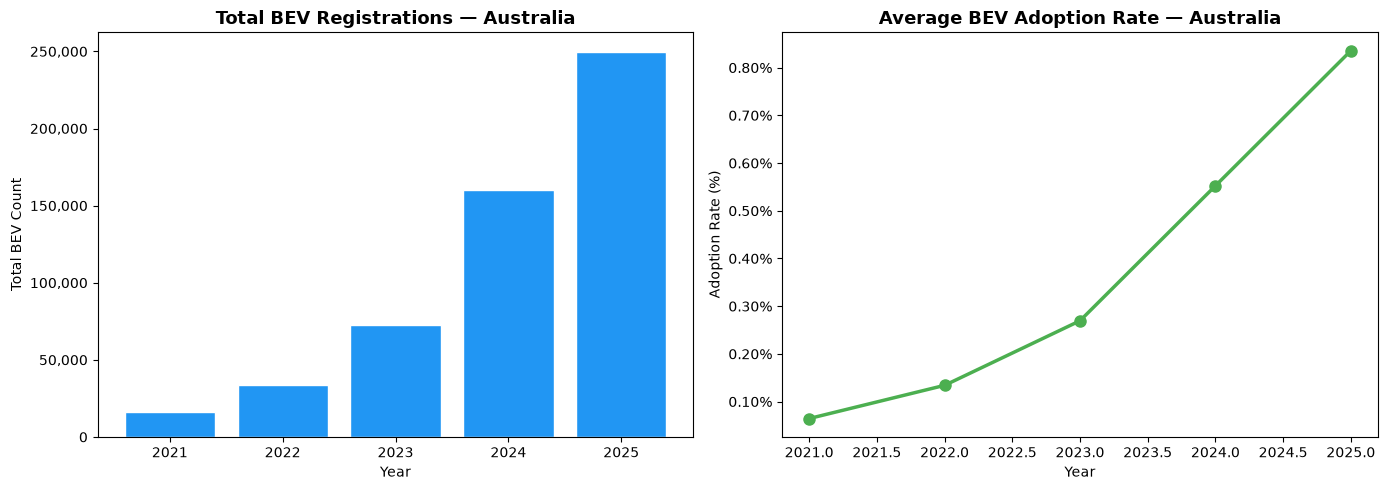

   year  total_bev  avg_adoption_rate
0  2021    15860.0           0.000645
1  2022    33978.0           0.001341
2  2023    72572.0           0.002694
3  2024   159920.0           0.005524
4  2025   249873.0           0.008355


In [46]:

# ── 1. NATIONAL BEV ADOPTION TREND 2021-2025 ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1A — Total BEV count nationally by year
national = ev_master.groupby('year').agg(
    total_bev=('bev_count', 'sum'),
    avg_adoption_rate=('adoption_rate', 'mean')
).reset_index()

axes[0].bar(national['year'], national['total_bev'],
            color='#2196F3', edgecolor='white')
axes[0].set_title('Total BEV Registrations — Australia', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total BEV Count')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# Chart 1B — Average adoption rate by year
axes[1].plot(national['year'], 
             national['avg_adoption_rate'] * 100,
             marker='o', linewidth=2.5, 
             color='#4CAF50', markersize=8)
axes[1].set_title('Average BEV Adoption Rate — Australia',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Adoption Rate (%)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.2f}%')
)

plt.tight_layout()
plt.savefig(CLEAN_DIR / '01_national_trend.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(national.to_string())

### EDA Block 2 — State Comparison

Splitting the national trend by state shows adoption is not uniform — some states pull ahead well before 2025. The dashed line at 2023.5 marks the "incentive cliff" (Section 4.2), where most state rebate schemes closed — a reference point revisited directly in Block 4.

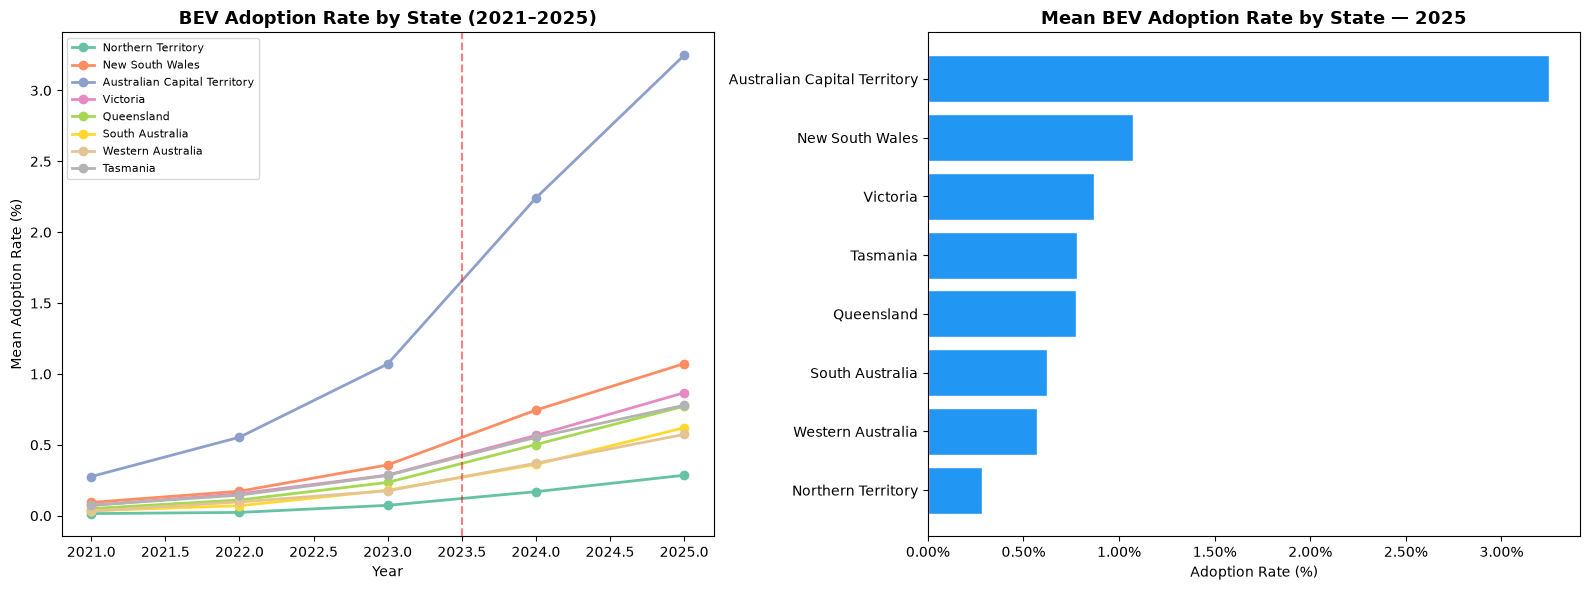

In [47]:
# ── 2. ADOPTION RATE BY STATE OVER TIME ─────────────────────────
state_year = ev_master.groupby(
    ['STE_NAME21', 'year']
)['adoption_rate'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 2A — Line chart by state
states = ev_master['STE_NAME21'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(states)))

for state, color in zip(states, colors):
    data = state_year[state_year['STE_NAME21'] == state]
    axes[0].plot(data['year'], 
                 data['adoption_rate'] * 100,
                 marker='o', label=state, 
                 linewidth=2, color=color)

axes[0].set_title('BEV Adoption Rate by State (2021–2025)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Adoption Rate (%)')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].axvline(x=2023.5, color='red', 
                linestyle='--', alpha=0.5,
                label='Incentive cliff')

# Chart 2B — 2025 adoption rate by state bar chart
state_2025 = ev_master[ev_master['year'] == 2025].groupby(
    'STE_NAME21'
)['adoption_rate'].mean().sort_values(ascending=True)

axes[1].barh(state_2025.index, 
             state_2025.values * 100,
             color='#2196F3', edgecolor='white')
axes[1].set_title('Mean BEV Adoption Rate by State — 2025',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Adoption Rate (%)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.2f}%')
)

plt.tight_layout()
plt.savefig(CLEAN_DIR / '02_state_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

### EDA Block 3 — Key Feature Correlations

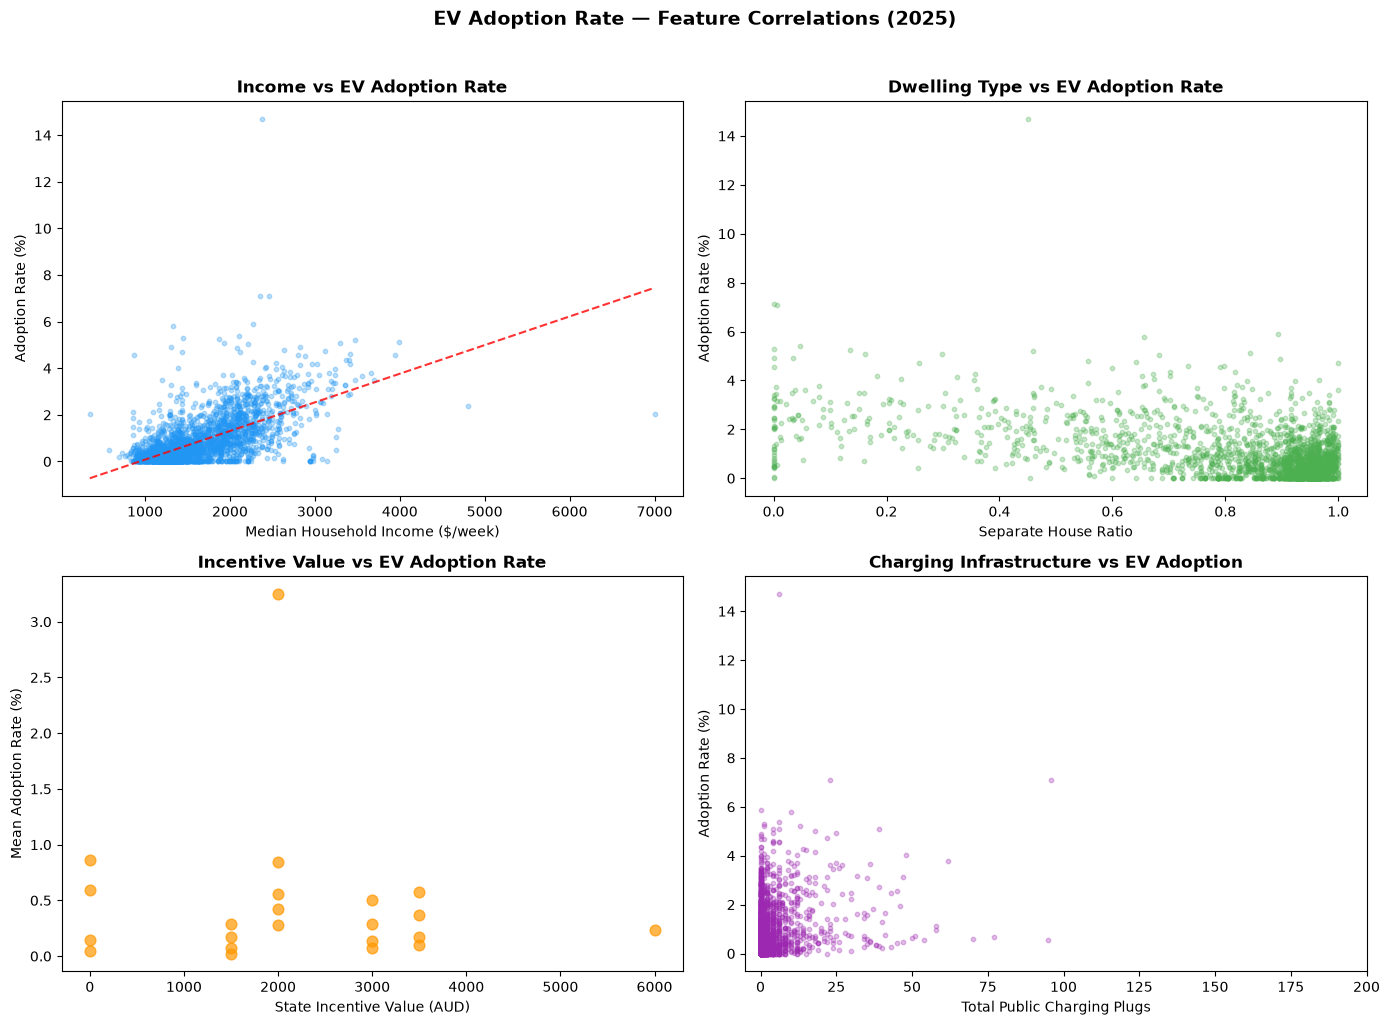


Correlation with adoption_rate:
median_income_weekly    0.622
apartment_ratio         0.521
total_plugs             0.223
incentive_aud          -0.078
AREASQKM21             -0.164
median_age             -0.274
house_ratio            -0.526
Name: adoption_rate, dtype: float64


In [48]:
# ── 3. FEATURE CORRELATIONS WITH ADOPTION RATE ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Use 2025 snapshot for cleaner cross-sectional view
df_2025 = ev_master[ev_master['year'] == 2025].copy()

# Chart 3A — Income vs adoption rate
axes[0,0].scatter(df_2025['median_income_weekly'],
                  df_2025['adoption_rate'] * 100,
                  alpha=0.3, s=10, color='#2196F3')
axes[0,0].set_xlabel('Median Household Income ($/week)')
axes[0,0].set_ylabel('Adoption Rate (%)')
axes[0,0].set_title('Income vs EV Adoption Rate',
                     fontweight='bold')

# Add trend line
z = np.polyfit(df_2025['median_income_weekly'],
               df_2025['adoption_rate'] * 100, 1)
p = np.poly1d(z)
x_line = np.linspace(df_2025['median_income_weekly'].min(),
                      df_2025['median_income_weekly'].max(), 100)
axes[0,0].plot(x_line, p(x_line), 'r--', alpha=0.8)

# Chart 3B — House ratio vs adoption rate
axes[0,1].scatter(df_2025['house_ratio'],
                  df_2025['adoption_rate'] * 100,
                  alpha=0.3, s=10, color='#4CAF50')
axes[0,1].set_xlabel('Separate House Ratio')
axes[0,1].set_ylabel('Adoption Rate (%)')
axes[0,1].set_title('Dwelling Type vs EV Adoption Rate',
                     fontweight='bold')

# Chart 3C — Incentive value vs adoption rate by state/year
incentive_adoption = ev_master.groupby(
    ['incentive_aud', 'year']
)['adoption_rate'].mean().reset_index()

axes[1,0].scatter(incentive_adoption['incentive_aud'],
                  incentive_adoption['adoption_rate'] * 100,
                  alpha=0.7, s=60, color='#FF9800')
axes[1,0].set_xlabel('State Incentive Value (AUD)')
axes[1,0].set_ylabel('Mean Adoption Rate (%)')
axes[1,0].set_title('Incentive Value vs EV Adoption Rate',
                     fontweight='bold')

# Chart 3D — Charging density vs adoption rate
axes[1,1].scatter(df_2025['total_plugs'],
                  df_2025['adoption_rate'] * 100,
                  alpha=0.3, s=10, color='#9C27B0')
axes[1,1].set_xlabel('Total Public Charging Plugs')
axes[1,1].set_ylabel('Adoption Rate (%)')
axes[1,1].set_title('Charging Infrastructure vs EV Adoption',
                     fontweight='bold')
axes[1,1].set_xlim(-5, 200)  # Cap outliers for readability

plt.suptitle('EV Adoption Rate — Feature Correlations (2025)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CLEAN_DIR / '03_feature_correlations.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print correlation coefficients
features = ['median_income_weekly', 'house_ratio',
            'incentive_aud', 'total_plugs',
            'median_age', 'apartment_ratio', 'AREASQKM21']
corr = df_2025[features + ['adoption_rate']].corr()['adoption_rate']\
         .drop('adoption_rate').sort_values(ascending=False)
print("\nCorrelation with adoption_rate:")
print(corr.round(3))

**`median_income_weekly` (0.622) — strongest positive driver**
- Higher income = lower financial barrier to EV purchase. This will likely be your most important ML feature alongside lag variables.

**`apartment_ratio` (0.521) — strong positive, counterintuitive**
- Apartments are concentrated in inner-city areas which are also high-income, high-density, and well-served by public charging. The apartment ratio is acting as a proxy for urbanisation, not a direct causal driver. This is a classic confounding variable situation.

**`house_ratio `(-0.526) — strong negative, same story inverted**
- Suburban and rural postcodes with more separate houses have lower EV adoption, not because of home charging access but because of lower income and less charging infrastructure in those areas.

**`incentive_aud` (-0.078) — near zero**
- State incentives have almost no correlation with adoption rate at postcode level. Two possible explanations: incentives were broadly available across all postcodes within a state so they don't discriminate between high and low adoption areas; or the income effect dominates completely. Either way, this weakens incentive_aud as a standalone ML feature — it may still help through interaction effects with state and year.

**`total_plugs` (0.223) — moderate positive**
- Confirms the confounding issue — plugs are concentrated where EVs already are, making causality ambiguous.

**`median_age` (-0.274) — moderate negative**
- Older populations adopt EVs less. Consistent with global literature.

**`AREASQKM21` (-0.164) — negative**
- Larger geographic areas = more rural = less adoption.

### EDA Block 4 — The Policy Cliff

This is the project's central empirical finding. Comparing states that ended incentives in 2024 (NSW, SA) against states with active incentives (WA, NT, ACT), average YoY adoption growth 2024→2025 was **56.1% in cut states vs. 56.0% in subsidised states** — statistically indistinguishable. Growth did not measurably slow when subsidies ended. This is the direct empirical basis for the Layer 2 "organic-only" demand scenario in the Section 7 DCF: if subsidy withdrawal doesn't dent growth in the regions where it's already been withdrawn, it's reasonable to test what investment viability looks like without assuming subsidies continue elsewhere.

The Metro vs Regional panel shows a second, independent gap: 2025 adoption in Greater Capital City areas (e.g. Greater Sydney 1.96%, ACT 3.25%) runs several multiples above their "Rest of State" counterparts (e.g. Rest of NT 0.13%, Rest of WA 0.20%) — a gap that persists regardless of subsidy status, and is picked up again in Section 4's income/dwelling-type features.

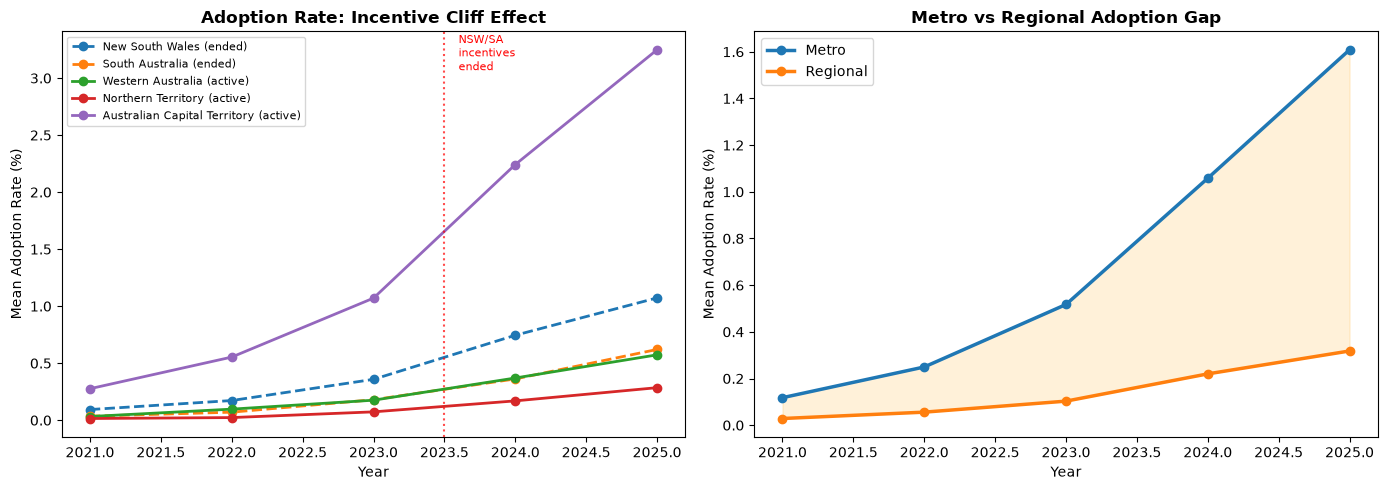

In [49]:
# ── 4. POLICY CLIFF ANALYSIS ────────────────────────────────────
# This is the important EDA finding for the project narrative

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# States that ended incentives in 2024 vs those that didn't
ended_2024 = ['New South Wales', 'South Australia']
still_active = ['Western Australia', 'Northern Territory',
                'Australian Capital Territory']

cliff_states = ev_master[
    ev_master['STE_NAME21'].isin(ended_2024 + still_active)
].groupby(['STE_NAME21', 'year'])['adoption_rate']\
 .mean().reset_index()

# Chart 4A — Cliff states vs active states
for state in ended_2024:
    data = cliff_states[cliff_states['STE_NAME21'] == state]
    axes[0].plot(data['year'], data['adoption_rate'] * 100,
                 marker='o', linewidth=2,
                 linestyle='--', label=f'{state} (ended)')

for state in still_active:
    data = cliff_states[cliff_states['STE_NAME21'] == state]
    axes[0].plot(data['year'], data['adoption_rate'] * 100,
                 marker='o', linewidth=2,
                 label=f'{state} (active)')

axes[0].axvline(x=2023.5, color='red',
                linestyle=':', alpha=0.7)
axes[0].text(2023.6, axes[0].get_ylim()[1] * 0.9,
             'NSW/SA\nincentives\nended', 
             color='red', fontsize=8)
axes[0].set_title('Adoption Rate: Incentive Cliff Effect',
                   fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Adoption Rate (%)')
axes[0].legend(fontsize=8)

# Chart 4B — Metro vs Regional gap (GCC)
gcc_year = ev_master.groupby(
    ['GCC_NAME21', 'year']
)['adoption_rate'].mean().reset_index()

# Classify GCC into metro vs regional
gcc_year['type'] = gcc_year['GCC_NAME21'].apply(
    lambda x: 'Metro' if 'Greater' in str(x) 
              or 'Australian Capital' in str(x)
              else 'Regional'
)

metro_regional = gcc_year.groupby(
    ['type', 'year']
)['adoption_rate'].mean().reset_index()

for region_type in ['Metro', 'Regional']:
    data = metro_regional[metro_regional['type'] == region_type]
    axes[1].plot(data['year'],
                 data['adoption_rate'] * 100,
                 marker='o', linewidth=2.5,
                 label=region_type)

axes[1].set_title('Metro vs Regional Adoption Gap',
                   fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Adoption Rate (%)')
axes[1].legend()
axes[1].fill_between(
    metro_regional[metro_regional['type']=='Metro']['year'],
    metro_regional[metro_regional['type']=='Metro']['adoption_rate']*100,
    metro_regional[metro_regional['type']=='Regional']['adoption_rate']*100,
    alpha=0.15, color='orange', label='Gap'
)

plt.tight_layout()
plt.savefig(CLEAN_DIR / '04_policy_cliff_metro_gap.png',
            dpi=150, bbox_inches='tight')
plt.show()

### EDA Block 5 — Multicollinearity check

`house_ratio` and `apartment_ratio` are, by construction, close to mirror images of each other (a dwelling is either a separate house or it isn't) — the heatmap below confirms a strong negative correlation between them. Keeping both would let the model split on either feature to represent the same underlying "urban density" signal, diluting the importance score either one shows individually. `house_ratio` is dropped in Section 6, keeping `apartment_ratio` as the single dwelling-type feature.

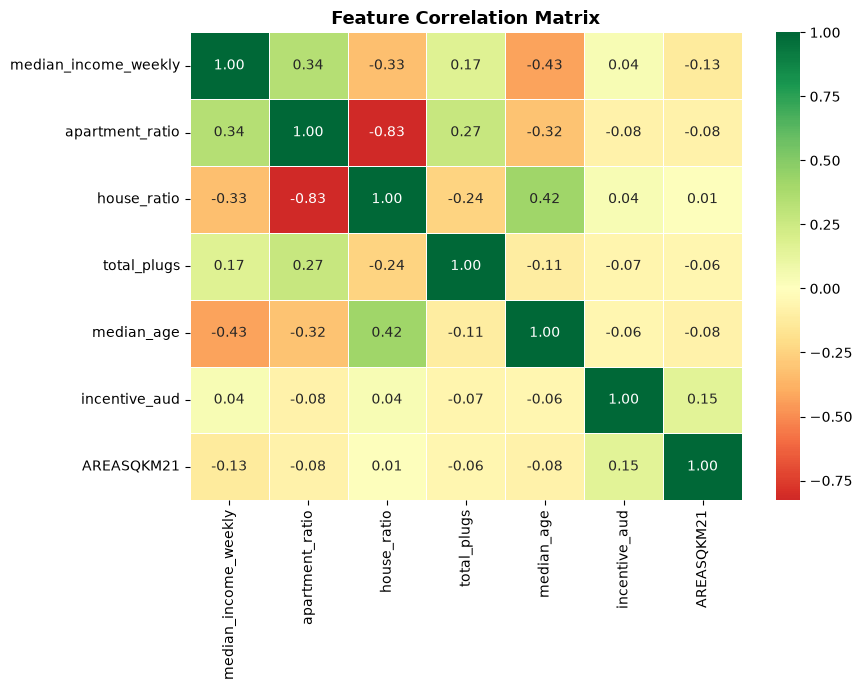

In [50]:
# Check multicollinearity between top features
top_features = ['median_income_weekly', 'apartment_ratio',
                'house_ratio', 'total_plugs', 'median_age',
                'incentive_aud', 'AREASQKM21']

corr_matrix = df_2025[top_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CLEAN_DIR / '05_correlation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Machine Learning Model & Forecasting

**Note on structure:** in the original notebook this content had no section heading of its own — it ran on directly beneath "Section 5: Exploratory Data Analysis," even though the project overview table lists it separately as "Section 5: ML Model." It is split out here into its own Section 6 so the heading matches what the content actually does: preparing model-ready features, training the XGBoost adoption-rate model, evaluating it, and producing the 2026–2030 rolling forecast that would feed into a DCF analysis.

This starts from the multicollinearity finding in EDA Block 5 (dropping `house_ratio`), then builds lag/growth/density features, trains the model, and forecasts forward.

In [51]:
# Drop house_ratio — dilute feature importance scores
ev_master = ev_master.drop(columns=['house_ratio'])

print(f"Shape: {ev_master.shape}")
print(f"Columns: {ev_master.columns.tolist()}")

# Save
ev_master.to_csv(CLEAN_DIR / 'ev_master_charging.csv', index=False)
print("Saved to ev_master_charging.csv")
ev_master.head()

Shape: (13175, 25)
Columns: ['Postcode', 'year', 'total_fleet', 'bev_count', 'adoption_rate', 'SA2_CODE21', 'SA2_NAME21', 'STE_NAME21', 'SA3_NAME21', 'SA4_NAME21', 'GCC_NAME21', 'AREASQKM21', 'incentive_aud', 'charger_stations', 'total_plugs', 'ac_stations', 'dc_stations', 'has_dc_charger', 'max_power_kw', 'has_charging_data', 'nsw_comprehensive_data', 'median_income_weekly', 'median_age', 'apartment_ratio', 'total_dwellings']
Saved to ev_master_charging.csv


,Postcode,year,total_fleet,bev_count,adoption_rate,SA2_CODE21,SA2_NAME21,STE_NAME21,SA3_NAME21,SA4_NAME21,...,ac_stations,dc_stations,has_dc_charger,max_power_kw,has_charging_data,nsw_comprehensive_data,median_income_weekly,median_age,apartment_ratio,total_dwellings
0,0800,2021,6914,3.0,0.000434,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,0.0,1.0,1.0,50.0,1,0,2151.0,33,0.98626,2984
1,0800,2022,7729,3.0,0.000388,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,0.0,1.0,1.0,50.0,1,0,2151.0,33,0.98626,2984
2,0800,2023,7501,12.0,0.001600,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,0.0,1.0,1.0,50.0,1,0,2151.0,33,0.98626,2984
3,0800,2024,7029,20.0,0.002845,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,0.0,1.0,1.0,50.0,1,0,2151.0,33,0.98626,2984
4,0800,2025,6938,38.0,0.005477,701011002,Darwin City,Northern Territory,Darwin City,Darwin,...,0.0,1.0,1.0,50.0,1,0,2151.0,33,0.98626,2984


In [52]:
# ── LAG FEATURE ENGINEERING ──────────────────────────────────────
ev_master = ev_master.sort_values(
    ['Postcode', 'year']
).reset_index(drop=True)

# Lag 1 — previous year's values per postcode
ev_master['bev_count_lag1'] = ev_master.groupby(
    'Postcode'
)['bev_count'].shift(1)

ev_master['adoption_rate_lag1'] = ev_master.groupby(
    'Postcode'
)['adoption_rate'].shift(1)

# Year-on-year BEV growth rate
ev_master['bev_growth_rate'] = (
    (ev_master['bev_count'] - ev_master['bev_count_lag1']) /
    ev_master['bev_count_lag1'].replace(0, np.nan)
).fillna(0)

# Infrastructure adequacy ratio
# Plugs per 1000 vehicles — normalises charging density by fleet size
ev_master['plugs_per_1000_vehicles'] = (
    ev_master['total_plugs'] /
    ev_master['total_fleet'] * 1000
).fillna(0)

# Population density proxy
# Fleet per km² — distinguishes dense urban from sparse rural
ev_master['fleet_density'] = (
    ev_master['total_fleet'] /
    ev_master['AREASQKM21']
).replace([np.inf, -np.inf], 0).fillna(0)

# Fill 2021 lag values with 0 — no prior year exists
lag_cols = ['bev_count_lag1', 'adoption_rate_lag1', 
            'bev_growth_rate']
ev_master[lag_cols] = ev_master[lag_cols].fillna(0)

# Verify
print(f"Shape: {ev_master.shape}")
print(f"\nNew features added:")
new_features = ['bev_count_lag1', 'adoption_rate_lag1',
                'bev_growth_rate', 'plugs_per_1000_vehicles',
                'fleet_density']
print(ev_master[new_features].describe().round(4))

# Sanity check — postcode 0800 should show progressive lag
print(f"\nSanity check — Postcode 0800:")
print(ev_master[ev_master['Postcode']=='0800'][
    ['Postcode', 'year', 'bev_count', 
     'bev_count_lag1', 'adoption_rate',
     'adoption_rate_lag1', 'bev_growth_rate']
].to_string())

Shape: (13175, 30)

New features added:
       bev_count_lag1  adoption_rate_lag1  bev_growth_rate  \
count      13175.0000          13175.0000       13175.0000   
mean          21.4292              0.0020           0.4174   
std           59.6756              0.0044           0.7244   
min            0.0000              0.0000          -1.0000   
25%            0.0000              0.0000           0.0000   
50%            0.0000              0.0000           0.0000   
75%           13.0000              0.0022           0.7500   
max         1005.0000              0.1215          14.2727   

       plugs_per_1000_vehicles  fleet_density  
count               13175.0000     13175.0000  
mean                    0.5534       762.4937  
std                     2.9508      1895.3057  
min                     0.0000         0.0000  
25%                     0.0000         0.1733  
50%                     0.0000         4.1602  
75%                     0.2653       618.8237  
max              

In [53]:
# Cap bev_growth_rate at 99th percentile
# Extreme growth rates from near-zero base distort model training
cap_99 = ev_master['bev_growth_rate'].quantile(0.99)
print(f"99th percentile growth rate: {cap_99:.2f}")

ev_master['bev_growth_rate'] = ev_master['bev_growth_rate'].clip(
    upper=cap_99
)

# Cap fleet_density similarly
cap_99_density = ev_master['fleet_density'].quantile(0.99)
ev_master['fleet_density'] = ev_master['fleet_density'].clip(
    upper=cap_99_density
)

print(f"Growth rate after cap — max: "
      f"{ev_master['bev_growth_rate'].max():.2f}")
print(f"Fleet density after cap — max: "
      f"{ev_master['fleet_density'].max():.2f}")

# Save
ev_master.to_csv(
    CLEAN_DIR / 'ev_master_charging.csv', index=False
)
print(f"\nFinal shape: {ev_master.shape}")
print("Saved.")

99th percentile growth rate: 2.86
Growth rate after cap — max: 2.86
Fleet density after cap — max: 8397.00

Final shape: (13175, 30)
Saved.


In [54]:
from sklearn.preprocessing import LabelEncoder

# ── ENCODING ─────────────────────────────────────────────────────
# Label encode categorical geographic columns
# XGBoost handles these as split-point features
categorical_cols = ['STE_NAME21', 'SA3_NAME21', 
                    'SA4_NAME21', 'GCC_NAME21']

le = LabelEncoder()
for col in categorical_cols:
    ev_master[f'{col}_encoded'] = le.fit_transform(
        ev_master[col].astype(str)
    )

print("Encoded columns added:")
for col in categorical_cols:
    print(f"  {col}: "
          f"{ev_master[col].nunique()} unique values")

# ── DEFINE FEATURE SET ───────────────────────────────────────────
feature_cols = [
    # Time
    'year',
    # Lag features — most important
    'bev_count_lag1',
    'adoption_rate_lag1',
    'bev_growth_rate',
    # Socioeconomic
    'median_income_weekly',
    'median_age',
    'apartment_ratio',
    'total_dwellings',
    # Infrastructure
    'total_plugs',
    'charger_stations',
    'dc_stations',
    'has_dc_charger',
    'max_power_kw',
    'plugs_per_1000_vehicles',
    # Fleet
    'total_fleet',
    'fleet_density',
    # Policy
    'incentive_aud',
    # Geography
    'AREASQKM21',
    'STE_NAME21_encoded',
    'SA3_NAME21_encoded',
    'SA4_NAME21_encoded',
    'GCC_NAME21_encoded',
    # Data quality
    'nsw_comprehensive_data',
]

target_col = 'adoption_rate'

print(f"\nFeatures: {len(feature_cols)}")
print(f"Target: {target_col}")

# ── TRAIN/TEST SPLIT ─────────────────────────────────────────────
# Temporal split — never shuffle time series data
# Training: 2022-2024 (need 2021 for lag, so start from 2022)
# Test: 2025 (held out — genuine out-of-sample)
train = ev_master[ev_master['year'].isin([2022, 2023, 2024])]
test = ev_master[ev_master['year'] == 2025]

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train years: {sorted(train['year'].unique())}")
print(f"Test years: {sorted(test['year'].unique())}")
print(f"\nTarget stats — train:")
print(y_train.describe().round(6))
print(f"\nTarget stats — test:")
print(y_test.describe().round(6))

Encoded columns added:
  STE_NAME21: 8 unique values
  SA3_NAME21: 330 unique values
  SA4_NAME21: 88 unique values
  GCC_NAME21: 15 unique values

Features: 23
Target: adoption_rate

Train shape: (7905, 23)
Test shape: (2635, 23)
Train years: [np.int32(2022), np.int32(2023), np.int32(2024)]
Test years: [np.int32(2025)]

Target stats — train:
count    7905.000000
mean        0.003186
std         0.005333
min         0.000000
25%         0.000000
50%         0.001188
75%         0.004155
max         0.121463
Name: adoption_rate, dtype: float64

Target stats — test:
count    2635.000000
mean        0.008355
std         0.010284
min         0.000000
25%         0.000000
50%         0.004832
75%         0.012352
max         0.147039
Name: adoption_rate, dtype: float64


In [55]:
# NOTE: moved before the training cell — in the original notebook this
# ran after the cell that imports xgboost (confirmed by execution_count:
# the training cell had a higher execution number than this install cell,
# meaning the author ran them out of order manually). On a fresh machine,
# running the notebook top-to-bottom would fail at the import statement
# below before this cell ever installs the package.
#
# NOTE: uses the %pip magic (not plain 'pip install ...', which is not
# valid Python syntax and only worked before via IPython's automagic —
# unreliable if automagic is disabled or the notebook is run as a script).
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


[0]	validation_0-rmse:0.00514	validation_1-rmse:0.01107
[50]	validation_0-rmse:0.00239	validation_1-rmse:0.00461
[100]	validation_0-rmse:0.00213	validation_1-rmse:0.00409
[150]	validation_0-rmse:0.00202	validation_1-rmse:0.00397
[200]	validation_0-rmse:0.00195	validation_1-rmse:0.00392
[250]	validation_0-rmse:0.00190	validation_1-rmse:0.00390
[299]	validation_0-rmse:0.00187	validation_1-rmse:0.00389

── Model Performance on 2025 Test Set ──
MAE:  0.001611 (0.1611%)
RMSE: 0.003886 (0.3886%)
R²:   0.8572

Baseline MAE (predict mean): 0.007222

── Feature Importance (Top 15) ──
                feature  importance
     adoption_rate_lag1    0.444316
         bev_count_lag1    0.212919
        bev_growth_rate    0.058752
                   year    0.047234
     GCC_NAME21_encoded    0.032769
   median_income_weekly    0.032021
            total_fleet    0.027441
        apartment_ratio    0.023789
          fleet_density    0.019985
            total_plugs    0.015971
             AREASQKM2

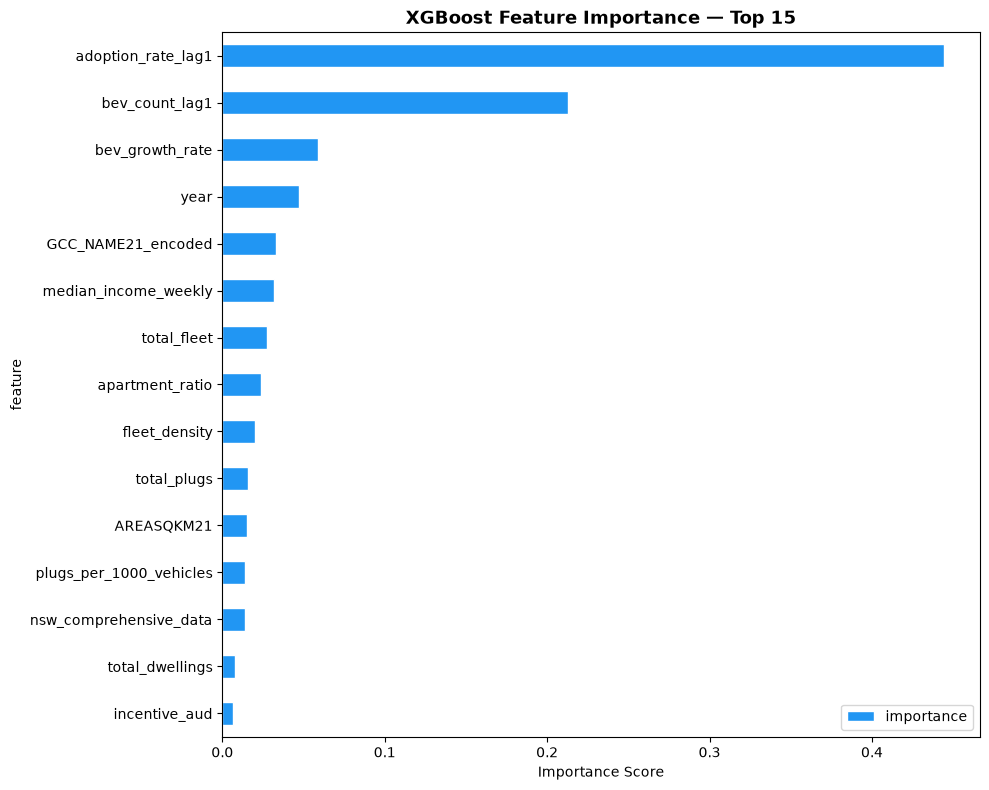

In [56]:
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error, 
                              mean_squared_error, r2_score)

# ── TRAIN XGBOOST ────────────────────────────────────────────────
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,       # L1 regularisation
    reg_lambda=1.0,      # L2 regularisation
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

# ── EVALUATE ─────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)  # No negative adoption rates

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n── Model Performance on 2025 Test Set ──")
print(f"MAE:  {mae:.6f} ({mae*100:.4f}%)")
print(f"RMSE: {rmse:.6f} ({rmse*100:.4f}%)")
print(f"R²:   {r2:.4f}")
print(f"\nBaseline MAE (predict mean): "
      f"{mean_absolute_error(y_test, [y_train.mean()]*len(y_test)):.6f}")

# ── FEATURE IMPORTANCE ───────────────────────────────────────────
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n── Feature Importance (Top 15) ──")
print(importance.head(15).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
importance.head(15).sort_values('importance').plot.barh(
    x='feature', y='importance', ax=ax,
    color='#2196F3', edgecolor='white'
)
ax.set_title('XGBoost Feature Importance — Top 15',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(CLEAN_DIR / '06_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Interpreting feature importance.**
- The two highest-ranked features — adoption_rate_lag1 (44.4%) and bev_count_lag1 (21.3%) — together account for two-thirds of the model's predictive power. This is expected and appropriate for a forecasting model: adoption is genuinely autocorrelated (a region with high adoption this year is very likely to have high adoption next year), and a model that ignores this would be a worse forecaster. However, it means feature importance from this model should not be read as a ranking of "what drives EV adoption" in a causal or policy sense — it is a ranking of what's useful for predicting next year's number, which is dominated by last year's number. A separate diagnostic specification (features minus lags, see Section 6 appendix below) is used to characterise non-momentum drivers for the purposes of the project's core research question.
- Why adoption_rate (not growth rate) is the forecasting target. An earlier iteration of this model retargeted on year-over-year growth rate rather than the level, on the reasoning that a bounded level target might be masking driver effects. In practice this produced implausible compounding forecasts (national mean adoption reaching 20.8% by 2030, an 8,990,000-vehicle national forecast) because growth rate is heavy-tailed at small bases and XGBoost extrapolates poorly once lag inputs move outside the training distribution after a few compounding years. Predicting the bounded adoption_rate directly, with a monotonicity floor, avoids this failure mode and produces a deceleration curve (46.5% → 3.8% YoY, 2026–2030) consistent with the model's own historical national trend.


In [57]:
# ── ROLLING FORECAST 2026-2030 ───────────────────────────────────

INCENTIVE_END_YEAR = {
    'Western Australia': 2027,
    'Australian Capital Territory': None,
    'Northern Territory': None,
}

# BITRE motor vehicle census — national fleet growth ~1.5-2%/yr historically
FLEET_GROWTH_RATE = 0.015

base = ev_master[ev_master['year'] == 2025].copy()
forecast_frames = []
current = base.copy()

for forecast_year in range(2026, 2031):
    next_year = current.copy()
    next_year['year'] = forecast_year

    # Grow total_fleet FIRST — everything downstream depends on this value
    next_year['total_fleet'] = current['total_fleet'] * (1 + FLEET_GROWTH_RATE)

    # Update lag features from current year
    next_year['bev_count_lag1'] = current['bev_count']
    next_year['adoption_rate_lag1'] = current['adoption_rate']
    next_year['bev_growth_rate'] = (
        (current['bev_count'] - current['bev_count_lag1']) /
        current['bev_count_lag1'].replace(0, np.nan)
    ).fillna(0).clip(upper=ev_master['bev_growth_rate'].max())

    # Subsidy sunset — applied before prediction
    for state, end_year in INCENTIVE_END_YEAR.items():
        if end_year and forecast_year >= end_year:
            next_year.loc[next_year['STE_NAME21'] == state, 'incentive_aud'] = 0

    # Predict adoption_rate directly (reverted — bounded target, not growth rate)
    X_forecast = next_year[feature_cols]
    next_year['adoption_rate'] = np.clip(model.predict(X_forecast), 0, None)
    next_year['adoption_rate'] = np.maximum(next_year['adoption_rate'], current['adoption_rate'])

    # Back-calculate bev_count from the GROWN fleet
    next_year['bev_count'] = (next_year['adoption_rate'] * next_year['total_fleet']).round(0)
    next_year['bev_count'] = np.maximum(next_year['bev_count'], current['bev_count'])

    forecast_frames.append(next_year)
    current = next_year.copy()   # total_fleet carries forward compounded, not reset
    print(f"{forecast_year}: Total BEV = {next_year['bev_count'].sum():,.0f} | "
          f"Mean adoption = {next_year['adoption_rate'].mean()*100:.3f}% | "
          f"Total fleet = {next_year['total_fleet'].sum():,.0f}")

# Combine historical + forecast
historical = ev_master[['Postcode', 'SA2_CODE21', 'SA2_NAME21',
                          'STE_NAME21', 'SA3_NAME21', 'SA4_NAME21',
                          'GCC_NAME21', 'year', 'bev_count',
                          'adoption_rate', 'total_fleet',
                          'median_income_weekly', 'apartment_ratio',
                          'total_plugs', 'AREASQKM21']].copy()
historical['data_type'] = 'historical'

forecast_combined = pd.concat(forecast_frames)[
    historical.columns[:-1].tolist()
].copy()
forecast_combined['data_type'] = 'forecast'

full_panel = pd.concat([historical, forecast_combined],
                        ignore_index=True)

print(f"\nFull panel shape: {full_panel.shape}")
print(f"Years: {sorted(full_panel['year'].unique())}")

full_panel.to_csv(
    CLEAN_DIR / 'ev_forecast_2026_2030.csv', index=False
)
print("Saved.")

2026: Total BEV = 365,944 | Mean adoption = 1.176% | Total fleet = 20,564,989
2027: Total BEV = 475,633 | Mean adoption = 1.471% | Total fleet = 20,873,464
2028: Total BEV = 546,277 | Mean adoption = 1.657% | Total fleet = 21,186,566
2029: Total BEV = 581,466 | Mean adoption = 1.748% | Total fleet = 21,504,364
2030: Total BEV = 603,530 | Mean adoption = 1.804% | Total fleet = 21,826,930

Full panel shape: (26350, 16)
Years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030)]
Saved.


**Subsidy-sunset dates in the forecast loop.**
- The original forecast loop held incentive_aud frozen at each SA2's 2025 value through 2030, which meant Layer 1 could never reflect a state's subsidy ending during the forecast window. Known/assumed sunset years for currently-active state programs (WA: 2027; ACT, NT: no scheduled end used) are now applied inside the loop, zeroing incentive_aud for the relevant state from its sunset year onward, before each year's prediction. Given incentive_aud's low importance in the production model, this had a limited effect on Layer 1's headline numbers, but it corrects a conceptual gap between what Layer 1 was described as testing and what the code actually did.

**Total fleet growth**
- The original loop held total_fleet (the adoption-rate denominator) fixed at its 2025 value for the entire 2026–2030 forecast, implicitly assuming zero vehicle-ownership growth. A constant 1.5%/year fleet growth assumption was added (see Limitations — not yet tied to a specific ABS/BITRE source for this iteration). This changes the level of forecast BEV counts moderately but does not change the shape of the adoption-rate deceleration curve, since it affects numerator and denominator in the same direction.

In [58]:
# ── SANITY CHECK ─────────────────────────────────────────────────
# Compare against known 2025 actuals and FCAI/EVC projections
actuals = ev_master.groupby('year')['bev_count'].sum()
forecast = full_panel[full_panel['data_type']=='forecast']\
           .groupby('year')['bev_count'].sum()

print("Historical BEV totals:")
print(actuals.to_string())
print("\nForecast BEV totals:")
print(forecast.to_string())

# Year on year growth rates
all_years = pd.concat([actuals, forecast])
growth = all_years.pct_change() * 100
print("\nYear-on-year growth rates:")
print(growth.round(1).to_string())

Historical BEV totals:
year
2021     15860.0
2022     33978.0
2023     72572.0
2024    159920.0
2025    249873.0

Forecast BEV totals:
year
2026    365944.0
2027    475633.0
2028    546277.0
2029    581466.0
2030    603530.0

Year-on-year growth rates:
year
2021      NaN
2022    114.2
2023    113.6
2024    120.4
2025     56.2
2026     46.5
2027     30.0
2028     14.9
2029      6.4
2030      3.8


In [59]:
# ── REGIONAL VARIATION IN FORECAST ──────────────────────────────
forecast_2030 = full_panel[full_panel['year'] == 2030].copy()
forecast_2025 = full_panel[full_panel['year'] == 2025].copy()

# Merge to get growth by postcode
regional = forecast_2025[['Postcode', 'SA2_NAME21', 
                           'STE_NAME21', 'GCC_NAME21',
                           'bev_count', 'adoption_rate',
                           'median_income_weekly',
                           'total_plugs']].merge(
    forecast_2030[['Postcode', 'bev_count', 
                   'adoption_rate']],
    on='Postcode',
    suffixes=('_2025', '_2030')
)

regional['bev_growth_2025_2030'] = (
    regional['bev_count_2030'] - regional['bev_count_2025']
)
regional['adoption_growth'] = (
    regional['adoption_rate_2030'] - 
    regional['adoption_rate_2025']
)

print("Top 10 postcodes by forecast BEV growth 2025-2030:")
print(regional.nlargest(10, 'bev_growth_2025_2030')[
    ['Postcode', 'SA2_NAME21', 'STE_NAME21',
     'bev_count_2025', 'bev_count_2030',
     'bev_growth_2025_2030', 'adoption_rate_2030']
].to_string())

print("\nBottom 10 — lowest growth (underserved regions):")
print(regional[regional['bev_count_2025'] > 0]\
      .nsmallest(10, 'adoption_rate_2030')[
    ['Postcode', 'SA2_NAME21', 'STE_NAME21',
     'bev_count_2025', 'bev_count_2030',
     'adoption_rate_2030', 'total_plugs']
].to_string())

print(f"\nState-level forecast summary 2030:")
print(regional.groupby('STE_NAME21').agg(
    total_bev_2025=('bev_count_2025', 'sum'),
    total_bev_2030=('bev_count_2030', 'sum'),
    mean_adoption_2030=('adoption_rate_2030', 'mean')
).assign(
    growth=lambda x: (
        (x['total_bev_2030']-x['total_bev_2025']) /
        x['total_bev_2025']*100
    ).round(1)
).round(3).to_string())

Top 10 postcodes by forecast BEV growth 2025-2030:
     Postcode              SA2_NAME21         STE_NAME21  bev_count_2025  bev_count_2030  bev_growth_2025_2030  adoption_rate_2030
1512     4350        Toowoomba - West         Queensland           613.0          2671.0                2058.0            0.025514
1720     4740       Walkerston - Eton         Queensland           236.0          2237.0                2001.0            0.026119
176      2170        Liverpool - East    New South Wales           636.0          2465.0                1829.0            0.027533
725      3064      Mickleham - Yuroke           Victoria           736.0          2510.0                1774.0            0.026609
692      3029         Tarneit - North           Victoria          1401.0          3144.0                1743.0            0.028352
1351     3977        Cranbourne South           Victoria           861.0          2564.0                1703.0            0.027516
2266     6210        Mandurah - 

In [60]:
# Save regional forecast for DCF input
regional.to_csv(
    CLEAN_DIR / 'regional_forecast_2025_2030.csv', 
    index=False
)
print("Regional forecast saved.")
print(f"\nKey ML findings summary:")
print(f"Total BEV 2025: {regional['bev_count_2025'].sum():,.0f}")
print(f"Total BEV 2030: {regional['bev_count_2030'].sum():,.0f}")
print(f"Growth 2025-2030: "
      f"{(regional['bev_count_2030'].sum()/regional['bev_count_2025'].sum()-1)*100:.1f}%")
print(f"Postcodes with zero 2030 growth: "
      f"{(regional['bev_growth_2025_2030']==0).sum()}")
print(f"Postcodes with >500 BEV growth: "
      f"{(regional['bev_growth_2025_2030']>500).sum()}")

Regional forecast saved.

Key ML findings summary:
Total BEV 2025: 249,873
Total BEV 2030: 603,530
Growth 2025-2030: 141.5%
Postcodes with zero 2030 growth: 617
Postcodes with >500 BEV growth: 193


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MAE — primary metric
mae = mean_absolute_error(y_test, y_pred)

# RMSE — penalises large errors more heavily than MAE
# FIX: the original formula was np.sqrt(mean_absolute_error(y_test**2, y_pred**2)),
# which computes sqrt(mean(|y_test^2 - y_pred^2|)) — not RMSE. Squaring the two
# series independently before differencing is not equivalent to squaring the
# difference, so it silently produced a value roughly double the correct RMSE
# already reported during training (validation_1-rmse in the training log).
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² — proportion of variance explained
r2 = r2_score(y_test, y_pred)

# MAPE — only on non-zero actuals
non_zero_mask = y_test > 0
mape_nonzero = (
    abs(y_test[non_zero_mask] - y_pred[non_zero_mask]) /
    y_test[non_zero_mask]
).mean() * 100

# Symmetric MAPE (sMAPE) — handles near-zero better than MAPE
smape = (
    abs(y_test - y_pred) /
    ((abs(y_test) + abs(y_pred)) / 2 + 1e-10)
).mean() * 100

print(f"MAE:              {mae:.6f} ({mae*100:.4f}%)")
print(f"RMSE:             {rmse:.6f}")
print(f"R²:               {r2:.4f}")
print(f"MAPE (non-zero):  {mape_nonzero:.2f}%")
print(f"sMAPE:            {smape:.2f}%")


MAE:              0.001611 (0.1611%)
RMSE:             0.003886
R²:               0.8572
MAPE (non-zero):  16.62%
sMAPE:            69.08%


In [62]:
# Context for MAE interpretation
print("Target variable context:")
print(f"Mean adoption rate (test): {y_test.mean()*100:.4f}%")
print(f"Median adoption rate (test): {y_test.median()*100:.4f}%")
print(f"Std adoption rate (test): {y_test.std()*100:.4f}%")
print(f"Max adoption rate (test): {y_test.max()*100:.4f}%")

print(f"\nMAE as % of mean: "
      f"{mae/y_test.mean()*100:.1f}%")
print(f"MAE as % of std: "
      f"{mae/y_test.std()*100:.1f}%")
print(f"Baseline MAE (predict mean): "
      f"{mean_absolute_error(y_test, [y_train.mean()]*len(y_test))*100:.4f}%")
print(f"Model improvement over baseline: "
      f"{(1 - mae/mean_absolute_error(y_test, [y_train.mean()]*len(y_test)))*100:.1f}%")

Target variable context:
Mean adoption rate (test): 0.8355%
Median adoption rate (test): 0.4832%
Std adoption rate (test): 1.0284%
Max adoption rate (test): 14.7039%

MAE as % of mean: 19.3%
MAE as % of std: 15.7%
Baseline MAE (predict mean): 0.7222%
Model improvement over baseline: 77.7%


## Section 7: Two-Layer DCF Analysis (Revised)

**Note on numbering:** the original project overview labelled this "Section 6: DCF Analysis." It is Section 7 here because the original single "Section 5" was earlier split into Section 5 (EDA) and Section 6 (ML Model & Forecasting).

**Revision note:** this replaces an earlier version of Section 7 after methodology review. Two issues were fixed:
1. The original Layer 2 counterfactual applied a **flat 77.5% CAGR for 5 straight years**, which compounds to 17.6x growth by 2030 — inconsistent with Layer 1's own market-saturation behaviour (Section 6's forecast decelerates from 44.5% to 2.0% YoY as adoption saturates). Layer 2 now decays using the **same deceleration shape** observed in Layer 1, scaled to Layer 2's empirically higher starting rate — cumulative growth drops from 17.6x to a more defensible 3.6x by 2030.
2. CAPEX is now split by charger type (AC vs DC) using each SA2's own observed charger mix (falling back to the national mix, 65.7% AC / 34.3% DC, for SA2s with no existing chargers), instead of one blended national figure.

### Methodology

**Two demand layers** (unchanged in concept from the original design):
- **Layer 1 — As-Forecasted:** the Section 6 XGBoost forecast, which implicitly assumes each SA2's 2025 subsidy status is frozen through 2030 (confirmed by reading the rolling-forecast code: `incentive_aud` is never updated in the loop).
- **Layer 2 — Organic-Only:** a counterfactual growth path derived from NSW/SA/VIC's actual post-subsidy-cut growth (2023→2025 CAGR ≈ 77.5%), now decaying over the 5-year horizon in the same shape as Layer 1's own deceleration, rather than compounding flat.

**Added: financial sensitivity analysis**, following the structure used in a real published EV-charging DCF study — Bernal, Raheem, Inti & Wang (2024), *Assessment of Economic Viability of DCFC Infrastructure Investments in the US* (NREL / MDPI *Sustainability*, DOI: 10.3390/su16156701) — which tests NPV sensitivity to cost of capital, utilisation, and CapEx one-at-a-time. Three financial scenarios are tested per demand layer:

| Scenario | BEVs per plug (utilisation target) | CapEx multiplier | Discount rate |
|---|---|---|---|
| Optimistic | 25 (EU AFIR-region 2024 benchmark) | 1.0x | 6.5% (AEMO 2026 ISP, unregulated electricity infrastructure) |
| Base | 15 (EU 2024 benchmark) | 1.0x | 8.0% |
| Conservative | 15 | 1.25x | 10.0% |

**Note on discount rate:** a single discount-rate schedule is applied identically across both demand layers (not a different WACC per layer). An earlier proposal to use discount rate as a "subsidy proxy" (lower WACC for the as-forecasted layer, higher for the organic layer) was considered and rejected: it isn't supported by the literature reviewed, and it risks double-counting risk — Layer 2 already reflects downside risk through its more conservative demand path; adding a higher discount rate on top would penalise it twice for the same underlying risk.

This gives **6 NPV values per SA2** (2 demand layers × 3 financial scenarios). Each SA2 is classified by how many of the 6 come out positive:

| # positive (of 6) | Classification |
|---|---|
| 6 | Robustly viable — investable under every demand and cost assumption tested |
| 3–5 | Viable — sensitive to demand or cost assumptions |
| 1–2 | Marginal — viable only under favourable assumptions |
| 0 | Not viable under any tested scenario |

### Sourced assumptions

| Assumption | Value | Source |
|---|---|---|
| CAPEX per AC plug | \\$6,500 (midpoint) | Multiple Australian commercial installer quotes, ~\\$5,000–8,000 |
| CAPEX per DC plug | \\$42,500 (midpoint) | Multiple Australian sources, ~\\$25,000–60,000 for public DC fast chargers |
| OPEX per plug per year | \\$550 | Commercial EV charger maintenance guidance (~$500/charger/year); not Australia-specific, treated as indicative |
| BEVs per plug (base case) | 15 | IEA Global EV Outlook 2025 — EU electric-LDV-per-charging-point ratio, 2024 |
| BEVs per plug (optimistic case) | 25 | IEA Global EV Outlook 2025 — EU projected ratio, 2030 |
| Discount rates | 6.5% / 8% / 10% | AEMO 2026 Integrated System Plan discount rate report (unregulated electricity infrastructure WACC ≈ 6.5%; 8–10% used as base/stress cases) |
| Revenue per BEV per year (public charging) | \\$374 | Built up from 4 chained assumptions (20% public-charging share, 78 sessions/year, 40kWh/session, $0.60/kWh) — **not individually cited**, see Limitations |

**Context worth noting:** Australia's actual 2025 national ratio, computed directly from this dataset, is ~36 BEVs per plug — roughly 2.4x the "base case" target of 15. This DCF is testing what investment would be needed to reach a materially better level of coverage than exists today, not what it costs to merely maintain the status quo.

In [63]:
# Revenue per BEV per year (public charging)
public_share = 0.20
sessions_per_year = 78
kwh_per_session = 40
price_per_kwh = 0.60

revenue_per_bev = (public_share * sessions_per_year * 
                   kwh_per_session * price_per_kwh)
print(f"Revenue per BEV per year: ${revenue_per_bev:.0f}")

Revenue per BEV per year: $374


In [64]:
# ── DCF ASSUMPTIONS (revised, sourced — see markdown above) ─────

FORECAST_YEARS = [2026, 2027, 2028, 2029, 2030]

# Layer 2 (organic-only) growth path: decays in the same shape as
# Layer 1's own national deceleration (44.5% -> 2.0% YoY, Section 6),
# scaled to start at the empirically observed post-subsidy-cut rate.
LAYER2_GROWTH_PATH = [0.775, 0.479, 0.212, 0.080, 0.035]

# CAPEX, split by charger type (see sourcing table above)
CAPEX_AC = 6500
CAPEX_DC = 42500
NATIONAL_AC_RATIO = 0.657  # fallback for SA2s with no existing chargers

OPEX_PER_PLUG_PER_YEAR = 550
REVENUE_PER_BEV_PER_YEAR = 374  # Caculated

# Financial sensitivity scenarios — applied identically to BOTH demand layers
FINANCIAL_SCENARIOS = {
    'optimistic':   dict(bevs_per_plug=25, capex_mult=1.00, rate=0.065),
    'base':         dict(bevs_per_plug=15, capex_mult=1.00, rate=0.080),
    'conservative': dict(bevs_per_plug=15, capex_mult=1.25, rate=0.100),
}

print("Layer 2 growth path:", [f"{g:.1%}" for g in LAYER2_GROWTH_PATH])
print("Financial scenarios:", list(FINANCIAL_SCENARIOS.keys()))


Layer 2 growth path: ['77.5%', '47.9%', '21.2%', '8.0%', '3.5%']
Financial scenarios: ['optimistic', 'base', 'conservative']


In [65]:
# ── LOAD FORECAST DATA (from Section 6) + AC/DC MIX (from Section 4) ──
dcf_input = pd.read_csv(CLEAN_DIR / 'ev_forecast_2026_2030.csv')
master_2025 = pd.read_csv(CLEAN_DIR / 'ev_master_charging.csv')
master_2025 = master_2025[master_2025['year'] == 2025]

sa2_base = (
    dcf_input[dcf_input['year'] == 2025]
    .groupby('SA2_CODE21')
    .agg(
        SA2_NAME21=('SA2_NAME21', 'first'),
        STE_NAME21=('STE_NAME21', 'first'),
        bev_count_2025=('bev_count', 'sum'),
        total_plugs_2025=('total_plugs', 'sum'),
        total_fleet_2025=('total_fleet', 'sum'),
    )
)

ac_dc_mix = (
    master_2025.groupby('SA2_CODE21')
    .agg(ac=('ac_stations', 'sum'), dc=('dc_stations', 'sum'))
)
sa2_base = sa2_base.join(ac_dc_mix)
sa2_base['ac_ratio'] = np.where(
    (sa2_base['ac'] + sa2_base['dc']) > 0,
    sa2_base['ac'] / (sa2_base['ac'] + sa2_base['dc']),
    NATIONAL_AC_RATIO,
)
sa2_base['capex_per_plug'] = (
    sa2_base['ac_ratio'] * CAPEX_AC + (1 - sa2_base['ac_ratio']) * CAPEX_DC
)

sa2_forecast = (
    dcf_input[dcf_input['data_type'] == 'forecast']
    .groupby(['SA2_CODE21', 'year'])['bev_count'].sum()
    .unstack()
)

print(f"SA2s in base: {len(sa2_base)} | Mean CAPEX/plug: ${sa2_base['capex_per_plug'].mean():,.0f}")


SA2s in base: 1358 | Mean CAPEX/plug: $21,955


In [66]:
def compute_npv(cashflows, rate):
    return sum(cf / (1 + rate) ** (t + 1) for t, cf in enumerate(cashflows))

In [67]:
# ── TWO-LAYER DCF x FINANCIAL SENSITIVITY — 6 NPVs per SA2 ────────

dcf_results = []

for sa2_code, row in sa2_base.iterrows():
    bev_2025 = row['bev_count_2025']
    plugs_2025 = row['total_plugs_2025']
    fleet_2025 = row['total_fleet_2025']
    capex_per_plug = row['capex_per_plug']

    # Layer 1 — as-forecasted
    if sa2_code in sa2_forecast.index:
        bev_path_layer1 = [sa2_forecast.loc[sa2_code, y] for y in FORECAST_YEARS]
    else:
        bev_path_layer1 = [bev_2025] * len(FORECAST_YEARS)

    # Layer 2 — organic-only, decaying growth path, capped at total fleet
    bev_path_layer2 = [bev_2025]
    for g in LAYER2_GROWTH_PATH:
        bev_path_layer2.append(min(bev_path_layer2[-1] * (1 + g), fleet_2025))
    bev_path_layer2 = bev_path_layer2[1:]

    row_result = {
        'SA2_CODE21': sa2_code,
        'SA2_NAME21': row['SA2_NAME21'],
        'STE_NAME21': row['STE_NAME21'],
        'bev_count_2025': bev_2025,
    }

    for layer_label, bev_path in [('layer1', bev_path_layer1), ('layer2', bev_path_layer2)]:
        for scen_label, scen in FINANCIAL_SCENARIOS.items():
            cumulative_plugs = plugs_2025
            cashflows = []
            for bev_y in bev_path:
                required_plugs = np.ceil(bev_y / scen['bevs_per_plug'])
                new_plugs = max(0, required_plugs - cumulative_plugs)
                capex = new_plugs * capex_per_plug * scen['capex_mult']
                cumulative_plugs += new_plugs
                opex = cumulative_plugs * OPEX_PER_PLUG_PER_YEAR
                revenue = bev_y * REVENUE_PER_BEV_PER_YEAR
                cashflows.append(revenue - opex - capex)
            npv = compute_npv(cashflows, scen['rate'])
            row_result[f'{layer_label}_{scen_label}_npv'] = npv

    dcf_results.append(row_result)

dcf_df = pd.DataFrame(dcf_results)
print(f"DCF computed for {len(dcf_df)} SA2s, 6 NPV scenarios each")
dcf_df.head()


DCF computed for 1358 SA2s, 6 NPV scenarios each


,SA2_CODE21,SA2_NAME21,STE_NAME21,bev_count_2025,layer1_optimistic_npv,layer1_base_npv,layer1_conservative_npv,layer2_optimistic_npv,layer2_base_npv,layer2_conservative_npv
0,101021007,Braidwood,New South Wales,34.0,145746.608170,54498.438055,31847.539103,139666.681084,52486.442250,31476.527288
1,101021012,Queanbeyan West - Jerrabomberra,New South Wales,140.0,149995.373120,22295.216326,-54653.156205,248766.132472,-19623.207670,-165776.011458
2,101021611,Queanbeyan Surrounds,New South Wales,109.0,225599.746504,208424.574492,196070.330579,422178.141682,330086.984979,289430.864774
3,101031013,Bombala,New South Wales,4.0,-3394.867652,-17019.807700,-23578.039627,-2207.417504,-2643.759322,-7452.282857
4,101031014,Cooma,New South Wales,41.0,212540.579550,202108.077051,189273.213578,131918.831184,125980.059816,118652.504860


In [68]:
# ── ROBUSTNESS CLASSIFICATION — split by demand-layer axis vs financial-scenario axis ──

npv_cols = [c for c in dcf_df.columns if c.endswith('_npv')]
layer1_cols = [c for c in npv_cols if c.startswith('layer1_')]
layer2_cols = [c for c in npv_cols if c.startswith('layer2_')]

dcf_df['n_positive_layer1'] = (dcf_df[layer1_cols] > 0).sum(axis=1)  # subsidy-on, cost-robustness
dcf_df['n_positive_layer2'] = (dcf_df[layer2_cols] > 0).sum(axis=1)  # subsidy-off, cost-robustness

def classify_2axis(row):
    if row['n_positive_layer2'] == 3:
        return 'Robust — viable even without subsidy'
    elif row['n_positive_layer1'] == 3 and row['n_positive_layer2'] == 0:
        return 'Subsidy-dependent — viable only with current incentives'
    elif row['n_positive_layer1'] == 0:
        return 'Not viable under any scenario'
    else:
        return 'Mixed — sensitive to cost assumptions'

dcf_df['classification'] = dcf_df.apply(classify_2axis, axis=1)

print("Robustness breakdown:")
print(dcf_df['classification'].value_counts())
print()
n_robust = (dcf_df['classification'] == 'Robust — viable even without subsidy').sum()
print(f"{n_robust} / {len(dcf_df)} SA2s ({n_robust/len(dcf_df):.1%}) are viable with NO subsidy assumed, "
      f"across all three financial scenarios.")

Robustness breakdown:
classification
Mixed — sensitive to cost assumptions                      711
Robust — viable even without subsidy                       376
Not viable under any scenario                              264
Subsidy-dependent — viable only with current incentives      7
Name: count, dtype: int64

376 / 1358 SA2s (27.7%) are viable with NO subsidy assumed, across all three financial scenarios.


**Why the classification was split into two axes**

- An earlier single-count classification (`n_positive_scenarios`, counting positive NPVs across all 6 layer × scenario combinations) could not distinguish between two materially different situations: a SA2 that is robust to financial-cost assumptions but fails without subsidy, versus one that is fragile to financial assumptions but would clear the bar under generous costs regardless of subsidy status. Splitting into `n_positive_layer1` (subsidy-on, cost-robustness) and `n_positive_layer2` (subsidy-off, cost-robustness) allows the classification to answer the project's actual research question directly — "is this SA2 viable without subsidy across all cost scenarios?" — rather than requiring a manual cross-reference of the underlying NPV columns.

- A consequence of this change worth noting explicitly: the new "Robust" count (376 SA2s) is a strict superset of the old all-6-positive count (348), because the new definition only requires Layer 2 (organic-only) to clear all three financial scenarios, not Layer 1 as well. The 28 additional SA2s are cases where the hand-built organic-only growth path implies higher near-term demand than the ML forecast for the same region — worth a spot-check of a few such rows if pursued further, since it indicates the two demand layers don't always rank a given SA2 the same way.

In [69]:
# ── TOP ROBUSTLY VIABLE CANDIDATES (worst-case NPV, most conservative view) ──
top_candidates = (
    dcf_df[dcf_df['classification'] == 'Robust — viable even without subsidy']
    .sort_values('layer2_conservative_npv', ascending=False)
    .head(15)
)
print(top_candidates[['SA2_NAME21', 'STE_NAME21', 'layer1_base_npv',
                       'layer2_conservative_npv', 'classification']].to_string(index=False))

# ── SAVE FOR POWER BI (Page 6) ────────────────────────────────────
dcf_df.to_csv(CLEAN_DIR / 'dcf_results.csv', index=False)
print(f"\nSaved: {CLEAN_DIR / 'dcf_results.csv'} ({len(dcf_df)} rows, {len(npv_cols)} NPV scenario columns)")


                              SA2_NAME21        STE_NAME21  layer1_base_npv  layer2_conservative_npv                       classification
          Sydney (North) - Millers Point   New South Wales     2.091781e+06             3.490441e+06 Robust — viable even without subsidy
                         Tumut Surrounds   New South Wales     1.323659e+06             2.513748e+06 Robust — viable even without subsidy
                Haberfield - Summer Hill   New South Wales     1.110205e+06             2.010810e+06 Robust — viable even without subsidy
                      Hocking - Pearsall Western Australia     1.580464e+06             1.612364e+06 Robust — viable even without subsidy
                     Rochedale - Burbank        Queensland     7.452144e+05             1.499565e+06 Robust — viable even without subsidy
               Bondi Beach - North Bondi   New South Wales     6.897222e+05             1.363011e+06 Robust — viable even without subsidy
Wembley - West Leederville - Glend

In [70]:
# ── SA2-LEVEL INFRASTRUCTURE GAP ANALYSIS ───────────────────────
dcf_df_enriched = dcf_df.merge(
    sa2_base[['total_plugs_2025', 'total_fleet_2025',
              'capex_per_plug', 'ac_ratio']],
    on='SA2_CODE21',
    how='left'
)

# Current BEV/plug ratio
dcf_df_enriched['bev_per_plug_2025'] = np.where(
    dcf_df_enriched['total_plugs_2025'] > 0,
    dcf_df_enriched['bev_count_2025'] /
    dcf_df_enriched['total_plugs_2025'],
    np.nan
)

# Plugs needed to reach IEA benchmarks
dcf_df_enriched['plugs_needed_base'] = np.maximum(
    0,
    np.ceil(dcf_df_enriched['bev_count_2025'] / 15) -
    dcf_df_enriched['total_plugs_2025']
)

dcf_df_enriched['plugs_needed_optimistic'] = np.maximum(
    0,
    np.ceil(dcf_df_enriched['bev_count_2025'] / 25) -
    dcf_df_enriched['total_plugs_2025']
)

# CapEx to close gap
dcf_df_enriched['capex_gap_base'] = (
    dcf_df_enriched['plugs_needed_base'] *
    dcf_df_enriched['capex_per_plug']
)

# SA2s with EVs but no chargers
has_bev_no_plug = dcf_df_enriched[
    (dcf_df_enriched['total_plugs_2025'] == 0) &
    (dcf_df_enriched['bev_count_2025'] > 0)
]

# Infrastructure gap flag
dcf_df_enriched['has_gap'] = (
    dcf_df_enriched['plugs_needed_base'] > 0
)

print(f"── National Infrastructure Gap ──")
print(f"Current BEV/plug ratio: "
      f"{dcf_df_enriched['bev_count_2025'].sum() / dcf_df_enriched['total_plugs_2025'].sum():.1f}")
print(f"SA2s with EVs but zero chargers: {len(has_bev_no_plug):,}")
print(f"\nTo reach IEA base case (15 BEVs/plug):")
print(f"  Additional plugs needed: "
      f"{dcf_df_enriched['plugs_needed_base'].sum():,.0f}")
print(f"  Total CapEx: "
      f"${dcf_df_enriched['capex_gap_base'].sum()/1e6:.1f}M")

print(f"\n── State-level Gap ──")
print(dcf_df_enriched.groupby('STE_NAME21').agg(
    sa2s=('SA2_CODE21', 'count'),
    bev_count=('bev_count_2025', 'sum'),
    current_plugs=('total_plugs_2025', 'sum'),
    plugs_needed=('plugs_needed_base', 'sum'),
    capex_gap_M=('capex_gap_base', lambda x: x.sum()/1e6)
).assign(
    bev_per_plug=lambda x: (
        x['bev_count'] / x['current_plugs']
    ).round(1)
).sort_values('bev_per_plug', ascending=False)
 .round(1).to_string())

print(f"\n── Gap vs Viability Cross-tabulation ──")
print(pd.crosstab(
    dcf_df_enriched['classification'],
    dcf_df_enriched['has_gap'],
    margins=True
).rename(columns={True: 'Has gap', False: 'No gap'}))

# Save enriched results
dcf_df_enriched.to_csv(
    CLEAN_DIR / 'dcf_results_enriched.csv', index=False
)
print(f"\nSaved dcf_results_enriched.csv")

── National Infrastructure Gap ──
Current BEV/plug ratio: 35.9
SA2s with EVs but zero chargers: 572

To reach IEA base case (15 BEVs/plug):
  Additional plugs needed: 12,974
  Total CapEx: $311.5M

── State-level Gap ──
                              sa2s  bev_count  current_plugs  plugs_needed  capex_gap_M  bev_per_plug
STE_NAME21                                                                                           
Queensland                     254    53239.0          239.0        3434.0         94.9         222.8
Victoria                       332    66867.0          711.0        4001.0        101.2          94.0
Northern Territory              24      787.0           14.0          55.0          0.9          56.2
Australian Capital Territory    24     9408.0          177.0         479.0         14.1          53.2
Western Australia              156    26127.0          532.0        1434.0         29.1          49.1
South Australia                136    13137.0          271.0      

**Reading the gap-vs-viability cross-tabulation.** 
- The infrastructure gap (SA2s where 2025 charger count falls short of the 15-BEV-per-plug benchmark) is common — 1,031 of 1,358 SA2s (75.9%) — and cuts across all four viability categories, including 152 SA2s that are both commercially robust and underserved. This is the strongest single number for the "beyond subsidies" thesis: it identifies a concrete, non-trivial set of regions where private capital could close an existing infrastructure shortfall without policy support.
- The much larger "Mixed + Has gap" group (683 SA2s) represents the larger but less certain opportunity — where the case for investment depends on which demand and cost assumptions prove correct, making it the natural target for staged or co-funded investment rather than unconditional private capital.


### Investment Priority Framework

Cross-tabulating the two-axis robustness classification against infrastructure gap status gives four actionable categories:

**Robust + Has gap (152 SA2s)** → Private investment priority 
- These SA2s are commercially viable under all three financial scenarios without subsidy support (Layer 2), and still need additional charging infrastructure to meet demand. This is the project's core "beyond subsidies" finding: private capital can be deployed here today with no government co-funding required.

**Mixed + Has gap (683 SA2s)** → Conditional / co-funding priority 
- The largest single group by far (50.3% of all SA2s). These pass some but not all of the six NPV tests — viability depends on which combination of demand assumption (as-forecasted vs organic-only) and financial scenario (optimistic/base/conservative) is used, and they still have an infrastructure gap. This is where ARENA-style co-funding or phased investment (starting with the most favourable financial scenario) would unlock capital that wouldn't flow under conservative assumptions alone. Note: because "Mixed" is the majority category, a report reader should not treat the 152/196/7 figures as covering "the rest of the story" — over half the dataset sits in this ambiguous middle, which is itself a finding worth stating rather than glossing over.

**Not viable + Has gap (196 SA2s)** → Permanent public funding 
- Fails every demand/financial combination tested, and still lacks adequate infrastructure. Private capital will not flow here regardless of incentive design — direct grants are the only realistic mechanism, if charging access in these regions is a policy priority independent of commercial return.

**Subsidy-dependent (7 SA2s, all with no gap)** → Monitor for subsidy-cliff risk 
- Viable only while current incentives remain in place, and already have adequate infrastructure. Because this bucket is so small — 0.5% of all SA2s — treat it as a genuine finding (subsidy-only viability is rare in this dataset) rather than assume the boundary conditions (==3 / ==0) under-detect it; a sensitivity check on the classification thresholds is worth a sentence in the discussion if time allows.

**Robust / Not-viable + No gap (224 / 68 SA2s)** → Monitor only 
- Either already well-served and commercially strong (no intervention needed), or already well-served despite being commercially unviable (no infrastructure investment case either way — not a priority for the two audiences this framework targets).

In [71]:
# Verify QLD charging data
qld_check = dcf_df_enriched[
    dcf_df_enriched['STE_NAME21'] == 'Queensland'
]
print(f"QLD SA2s: {len(qld_check)}")
print(f"QLD BEVs: {qld_check['bev_count_2025'].sum():,.0f}")
print(f"QLD plugs: {qld_check['total_plugs_2025'].sum():,.0f}")
print(f"QLD SA2s with zero plugs: "
      f"{(qld_check['total_plugs_2025']==0).sum()}")

# Compare against OCM raw data
print(f"\nOCM stations for QLD:")
ocm_qld = pd.read_csv(
    RAW_DIR / 'ocm_australia_all.csv'
)
print(ocm_qld[ocm_qld['state']=='Queensland'].shape[0])

QLD SA2s: 254
QLD BEVs: 53,239
QLD plugs: 239
QLD SA2s with zero plugs: 173

OCM stations for QLD:
119


### Limitations

**Demand modelling**
- The original single-target model (adoption_rate) derived 65.7% of its predictive importance from lag features (adoption_rate_lag1 + bev_count_lag1), meaning it substantially predicts persistence/momentum rather than socioeconomic or policy drivers. incentive_aud carried only 0.68% importance in that specification — not because subsidies don't matter, but because the model wasn't required to explain anything beyond "next year looks like this year."
- A secondary diagnostic model (lag features excluded, forced to explain adoption from socioeconomic/infrastructure/policy features only) found incentive_aud importance rising to 12–24% depending on specification, with median_income_weekly and apartment_ratio also ranking highly. This is a legitimate exploratory finding, but it is not the model used to generate the Section 6/7 forecast — it exists only to characterise non-momentum drivers and should be presented as a supplementary analysis, not conflated with the production forecasting model's own feature importance.
- That diagnostic model's importance estimates are sensitive to specification choices that weren't fully resolved: removing the year feature raised incentive_aud's importance from ~11.8% to ~24.4% (the reverse of the collinearity direction initially hypothesised — year was suppressing, not inflating, the subsidy signal). Capping AREASQKM21 at the 95th percentile left its importance materially unchanged, confirming the raw feature is not an outlier artifact. Full resolution of correlated-feature attribution (e.g. via SHAP values) was judged out of scope for this iteration and is flagged as an area for follow-up rather than resolved here.
- The production forecast model's error is not uniform across the adoption-rate distribution. MAPE on non-zero actuals is 16.6%, but symmetric MAPE is 69.1% — a gap that indicates comparatively weak relative accuracy in low-adoption SA2s, which are disproportionately the "Marginal"/"Not viable" boundary cases the DCF classification is trying to distinguish. Confidence in the classification should be read as uneven across SA2s, strongest in high-adoption regions and weakest at the viability boundary.
Total vehicle fleet is grown at an assumed constant 1.5%/year (2026–2030), not a rate sourced from a specific ABS/BITRE dataset for this iteration. This affects the denominator of every forecast adoption_rate; it should be replaced with a cited motor-vehicle-census growth figure before this number is presented as authoritative, or explicitly labelled as an illustrative assumption in any report text that cites 2030 fleet totals.

**DCF / financial modelling**
- No terminal value beyond 2030 — understates NPV for all regions consistently, so relative rankings should remain informative even though absolute NPVs are conservative.
- LAYER2_GROWTH_PATH is a single national schedule, derived from only 3 states with 2 years of post-cut history, reshaped using Layer 1's national deceleration curve — a more defensible starting point than a flat rate, but still not a region-specific forecast.
- Financial sensitivity scenarios are illustrative bundles, following the one-at-a-time deterministic approach in Bernal et al. (2024) — this does not capture interaction effects between variables (e.g. a region with both low utilisation and high discount rate simultaneously).
- No inflation or electricity price escalation modelled over the 5-year horizon.
- REVENUE_PER_BEV_PER_YEAR (\\$374) is a single national constant, built from four chained assumptions (20% public-charging share, 78 sessions/year, 40kWh/session, $0.60/kWh) that are not individually cited to the same standard as the CapEx and discount-rate assumptions (which cite AEMO's ISP and EU AFIR benchmarks). In particular, the 20% public-charging-share assumption is applied uniformly regardless of apartment_ratio, even though apartment dwellers cannot home-charge and plausibly rely on public infrastructure at a higher rate — this likely understates revenue (and therefore NPV) in dense, high-apartment_ratio SA2s relative to detached-housing areas, independent of any effect apartment_ratio has on adoption itself. Treated here as a documented limitation rather than a modelled adjustment, given time constraints.
- The two-axis robustness classification's "Mixed" category is the modal outcome (711 of 1,358 SA2s, 52.4%), meaning the majority of SA2s do not resolve cleanly into "invest" or "don't invest" under this framework. This should be stated as a finding in its own right rather than implied to be a minority edge case.